---
# Deep Learning (COSC 2779 / 2792)
# Assignment 2: Deep Learning — Sequence Modelling

## Sridhar Srinath *(Student ID: **S4182099**)*
---
**What I'm building.** Litmus wants a tool that looks at the text of a meme and:
* **Part A:** says which of the 20 persuasion techniques it uses;
* **Part B:** points *where* in the text each technique is;
* **Part C:** helps answer the curriculum committee's four questions (bias, whether a zer-shot model would do, whether the two output agree, and whether it'll work for Australian year 10 students in 2026).

**How I approached it.** The only things I fixed before training were the evaluation setup (§3) and one rule for deciding whether a change is worth keeping (§4). After that, every step in §5 comes from something I measured in the step before. The pattern is always: run something, look at what it printed, explain what that means, then decide what to try next. The test set isn't touched until §7, once the design is locked in.

| § | What happens there |
|---|---|
| 1–2 | Load the data, sanity-check it, and explore it to decide the output format, metric and risks |
| 3 | Metrics, trivial baselines, targets and the cross-validation split |
| 4 | The model and how it's trained |
| 5 | Development, one measured step at a time |
| 6 | Train the final model, save it, reload it, time it |
| 7–8 | Test once, then dig into the errors and check the explanations |
| 9 | Part C: C1 bias, C2 zero-shot comparison, C3 head agreement, C4 Australian context |
| 10 | Final judgment and recommendation |

---
## 0. Setup

In [1]:
!pip install -q "transformers==4.51.3" "peft==0.14.0" "huggingface_hub==0.30.2" accelerate

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import os, re, json, time, random, copy, zipfile, glob, warnings
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from collections import Counter, defaultdict
import transformers
from datetime import datetime
from IPython.display import HTML, display
from peft import LoraConfig, get_peft_model
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0) if torch.cuda.is_available() else '','- transformers', transformers.__version__)

cuda Tesla T4 - transformers 4.51.3


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
SEED = 42
set_seed(SEED)

In [6]:
ENCODER_NAME = 'distilbert-base-uncased' # Starting encoder
MAX_LEN = 128 # MAX_LEN checked against token lengths
BATCH_SIZE = 16
N_FOLDS = 5 # 5-fold CV
STOP_FRAC = 0.10 # 10 % of each training fold used only for early stopping
MAX_EPOCHS = 15
PATIENCE = 3
PROBE_EPOCHS = 2
HEAD_LR = 1e-3 # Linear-probe learning rate for the new heads

**Constraints from brief, and how I'm meeting them**
* **Runs on the device:** only local models, no hosted APIs (this matters again in C2).
* **One T4:** latency is actually measured in §6, not assumed.
* **General-purpose encoders only:** DistilBERT and BERT-base, which were pretrained on Wikipedia and books and have never seen persuasion labels.
* **No extra data:** no outside corpora and no augmentation (reason in §2).
* **Neural networks only:** the keyword lists in C1/C4 are just for picking memes to analyse. They're never part of the tool.
* **A self-built part that gets trained:** the label head and span head in §4.

---
## 1. Data

The task-1 files have each meme's set of techniques (Part A) and the task-2 files have the character spans (Part B). I combine train and dev into one 751-meme development pool, because 751 memes is already small and splitting off a fixed dev set would waste data (more on that in §3). The test set stays unloaded until §7.

In [7]:
# Find the data folder (unzip the file if needed)
def find(pattern):
    hits = glob.glob(f'**/{pattern}', recursive=True) + glob.glob(f'../*/{pattern}') + glob.glob(f'../*/*/{pattern}')
    return [h for h in hits if '__MACOSX' not in h]

if not find('training_set_task1*'):
    for zip_path in find('*.zip'):
        with zipfile.ZipFile(zip_path) as z:
            if any('training_set_task1' in n for n in z.namelist()):
                z.extractall('data_2026_A2_extracted')

hits = find('training_set_task1*')
assert hits, f'training_set_task1.txt not found. Notebook folder: {os.getcwd()} contains {os.listdir(".")}'
DATA_DIR = os.path.dirname(hits[0])
print('Data folder:', DATA_DIR)

Data folder: data_2026_A2/data


In [8]:
ALL_22 = ['Appeal to authority', 'Appeal to fear/prejudice', 'Black-and-white Fallacy/Dictatorship', 'Causal Oversimplification',
          'Doubt', 'Exaggeration/Minimisation', 'Flag-waving', 'Glittering generalities (Virtue)', 'Loaded Language',
          "Misrepresentation of Someone's Position (Straw Man)", 'Name calling/Labeling', 'Obfuscation, Intentional vagueness, Confusion',
          'Presenting Irrelevant Data (Red Herring)', 'Reductio ad hitlerum', 'Repetition', 'Slogans', 'Smears',
          'Thought-terminating cliché', 'Whataboutism', 'Bandwagon', 'Transfer', 'Appeal to (Strong) Emotions']

if os.path.exists('techniques_list_task3.txt'):
    ALL_22 = [l.strip() for l in open('techniques_list_task3.txt', encoding='utf-8') if l.strip()]

# the last two are image-only techniques
TECHNIQUES = ALL_22[:20]
N_LABELS = len(TECHNIQUES)
T2I = {t: i for i, t in enumerate(TECHNIQUES)}

def load_split(name):
    t1 = json.load(open(os.path.join(DATA_DIR, f'{name}_set_task1.txt'), encoding='utf-8'))
    t2 = {d['id']: d for d in json.load(open(os.path.join(DATA_DIR, f'{name}_set_task2.txt'), encoding='utf-8'))}
    return [{'id': d['id'], 'text': d['text'], 'labels': set(d['labels']), 'spans': [(s['start'], s['end'], s['technique']) for s in t2[d['id']]['labels']]} for d in t1]

pool_docs = load_split('training') + load_split('dev')
labels_to_matrix = lambda sets: np.array([[1 if t in s else 0 for t in TECHNIQUES] for s in sets])
Y_pool = labels_to_matrix([d['labels'] for d in pool_docs])
print('Development pool:', len(pool_docs))
print('Techniques used:', len(set().union(*[d['labels'] for d in pool_docs])))
print('Outside the 20-label list:', set().union(*[d['labels'] for d in pool_docs]) - set(TECHNIQUES))
print('Label set: Union of span techniques:', sum(d['labels'] == {s[2] for s in d['spans']} for d in pool_docs), '/', len(pool_docs))

Development pool: 751
Techniques used: 20
Outside the 20-label list: set()
Label set: Union of span techniques: 751 / 751


**What this tells me**
* **751 / 751** memes have a label set that's exactly the union of their span techniques. So Part A and Part B aren't two separate annotations; the labels are just the spans summarised. That's a good reason to try **one model with two heads** instead of two models, and it's also why comparing the two heads in C3 makes sense.
* Exactly **20** techniques show up and none are outside the list, so the output layer gets 20 labels. The other two techniques in the full list of 22 are image-only, which doesn't apply to a text model.

---
## 2. Exploratory data analysis
The point of this section is to let the data decide a few design choices before any model exists.

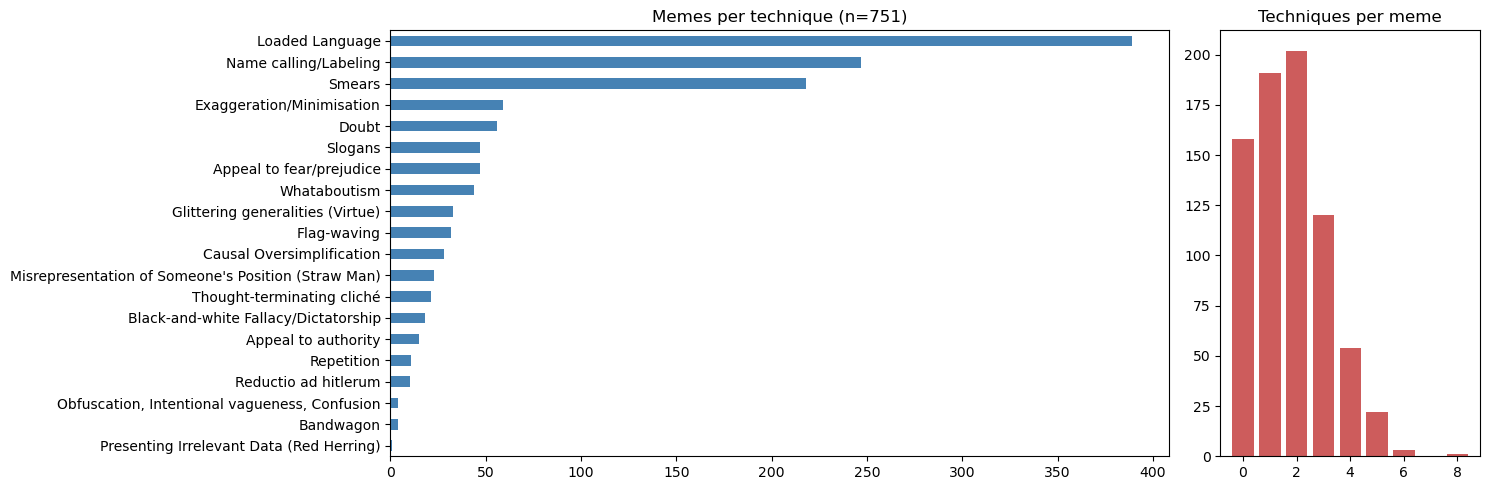

In [9]:
counts = pd.Series(Y_pool.sum(0), index=TECHNIQUES).sort_values(ascending=False)
n_per = Y_pool.sum(1)
fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [3, 1]})
counts.plot.barh(ax=ax[0], color='steelblue')
ax[0].invert_yaxis()
ax[0].set_title('Memes per technique (n=751)')
ax[1].bar(*np.unique(n_per, return_counts=True), color='indianred')
ax[1].set_title('Techniques per meme')
plt.tight_layout()
plt.show()

In [10]:
print(f'Most / Least frequent: {counts.max()}/{counts.min()}')

Most / Least frequent: 389/1


In [11]:
print(f'Techniques with <10 memes: {list(counts[counts < 10].index)}')

Techniques with <10 memes: ['Obfuscation, Intentional vagueness, Confusion', 'Bandwagon', 'Presenting Irrelevant Data (Red Herring)']


In [12]:
print(f'Memes with no technique: {(n_per == 0).mean():.0%}')
print(f'Mean techniques per meme: {n_per.mean():.2f}')

Memes with no technique: 21%
Mean techniques per meme: 1.74


In [13]:
# Span length and overlap
span_words = defaultdict(list)
whole = Counter()
overlap = 0
tagged = 0
docs_overlap = 0
for d in pool_docs:
    cover = [set() for _ in d['text']]
    for s, e, t in d['spans']:
        span_words[t].append(len(d['text'][s:e].split()))
        whole[t] += (e - s) >= 0.8 * len(d['text'].rstrip())
        for i in range(s, min(e, len(d['text']))): cover[i].add(t)
    real = [c for i, c in enumerate(cover) if c and not d['text'][i].isspace()]
    tagged += len(real)
    ov = sum(len(c) > 1 for c in real)
    overlap += ov
    docs_overlap += ov > 0
span_df = pd.DataFrame({'median words': {t: np.median(v) for t, v in span_words.items()}, 'share covering >80% of meme': {t: whole[t] / len(v) for t, v in span_words.items()}}).loc[counts.index].round(2)
display(span_df.head(10).T)

,Loaded Language,Name calling/Labeling,Smears,Exaggeration/Minimisation,Doubt,Slogans,Appeal to fear/prejudice,Whataboutism,Glittering generalities (Virtue),Flag-waving
median words,1.0,2.00,15.00,5.00,11.50,3.00,8.5,23.0,10.50,4.00
share covering >80% of meme,0.0,0.02,0.64,0.12,0.41,0.12,0.1,0.7,0.38,0.03


In [14]:
print(f'Tagged characters with 2+ techniques: {overlap / tagged:.0%}')
print(f'Memes with overlap: {docs_overlap}/{len(pool_docs)}')

Tagged characters with 2+ techniques: 36%
Memes with overlap: 373/751


In [15]:
# Length, casing, topic
tok0 = AutoTokenizer.from_pretrained(ENCODER_NAME)
n_tok = np.array([len(tok0(d['text'])['input_ids']) for d in pool_docs])
caps = np.mean([sum(c.isupper() for c in d['text']) / max(1, sum(c.isalpha() for c in d['text'])) > 0.7 for d in pool_docs])
us = np.mean([bool(re.search(r'trump|biden|obama|clinton|democrat|republican|liberal|conservative|covid|america', d['text'].lower())) for d in pool_docs])
au = sum(bool(re.search(r'australia|aussie|albanese|dutton|\blabor\b', d['text'].lower())) for d in pool_docs)
print(f'Max tokens {n_tok.max()} (> MAX_LEN: {(n_tok > MAX_LEN).sum()})')
print(f'Mostly-capitals memes {caps:.0%}, US politics/COVID memes {us:.0%}, Australian memes {au}')

Max tokens 101 (> MAX_LEN: 0)
Mostly-capitals memes 48%, US politics/COVID memes 33%, Australian memes 1


**What the exploration tells me, and the design decision each finding leads to**

| What the output shows | What it means | So I... |
|---|---|---|
| *Loaded Language* is in 389 memes, *Red Herring* in 1, and three techniques have fewer than 10 | The classes are really imbalanced, so any metric that pools every decision will be dominated by the top two or three techniques | use a metric that weights each technique equally (§3), and keep an eye out for rare techniques being ignored |
| Memes have 0 to 8 techniques each, and **21 %** have none | It's multi-label, and "nothing" is a valid answer | use one sigmoid per technique with binary cross-entropy. Softmax would force exactly one answer per meme, which is wrong here |
| **36 %** of tagged characters belong to 2+ techniques, across **373** memes | The same words often count for several techniques at once | make the span head output 20 independent yes/no values per token. Normal BIO tagging only allows one tag per token, so it can't represent this |
| *Loaded Language* spans are 1 word (median), but *Smears* covers over 80 % of the meme in 64 % of cases | Some techniques are single words, others are basically the whole meme | add a "highlight the whole meme" baseline in §3, because a character-level metric will reward over-highlighting |
| The longest meme is **101** tokens, so nothing gets cut off; **48 %** are mostly in capitals | Texts are short and caps are everywhere | set `MAX_LEN = 128`, and use uncased encoders so "LIBERALS" and "liberals" look the same |
| **33 %** mention US politics or COVID, and only **1** meme is Australian | The model could learn US names as shortcuts, and the actual deployment setting isn't in the data | test this directly with name swaps (C1) and an Australian shift (C4) |

**Where the data comes from.** Dimitrov et al. (2021) collected English memes from public Facebook groups during 2020, mostly US/Canadian political ones. Several annotators labelled each meme and then agreed on a final version.

A few things follow from that:
* The labels are human judgements, so the tool should present them as something to discuss, not as facts.
* I didn't add any other corpora, since their labels could overlap with this test set.
* I didn't use augmentation either. Swapping synonyms can change the technique itself ("traitor" → "opponent" removes the *Loaded Language*), so it doesn't preserve the label.

---
## 3. Evaluation framework
**Metrics**
* **Part A (primary): macro-F1** over the techniques that are present. The tool is supposed to teach every technique, not just the common ones, and the baseline table below shows why that matters.
* **Part B (primary): character-level macro-F1.** Predicted vs gold characters per technique. Characters give partial credit when a highlight overlaps the right words but isn't exact, which is fairer than all-or-nothing span matching.
* **Secondary:** micro-F1 and per-technique precision/recall, so I can see what's driving the macro score.

In [16]:
def doc_scores(Y, P):
    Y, P = np.asarray(Y), np.asarray(P).astype(int)
    tp, fp, fn = (Y * P).sum(0), ((1 - Y) * P).sum(0), (Y * (1 - P)).sum(0)
    f1 = np.where(2 * tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1), 0.0)
    return {'macro_f1': f1[Y.sum(0) > 0].mean(), 'micro_f1': 2 * tp.sum() / max(2 * tp.sum() + fp.sum() + fn.sum(), 1),
            'f1': f1, 'precision': np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1), 0.0),
            'recall': np.where(tp + fn > 0, tp / np.maximum(tp + fn, 1), 0.0), 'support': Y.sum(0)}

def char_sets(text, spans):
    out = defaultdict(set)
    for s, e, t in spans:
        out[t].update(i for i in range(s, min(e, len(text))) if not text[i].isspace())
    return out

def span_scores(docs, preds):
    tp, fp, fn = Counter(), Counter(), Counter()
    for d, p in zip(docs, preds):
        g, q = char_sets(d['text'], d['spans']), char_sets(d['text'], p)
        for t in TECHNIQUES:
            tp[t] += len(g[t] & q[t])
            fp[t] += len(q[t] - g[t])
            fn[t] += len(g[t] - q[t])
    f1 = {t: 2 * tp[t] / (2 * tp[t] + fp[t] + fn[t]) if 2 * tp[t] + fp[t] + fn[t] else 0.0 for t in TECHNIQUES}
    T, FP, FN = sum(tp.values()), sum(fp.values()), sum(fn.values())
    return {'macro_f1': np.mean([f1[t] for t in TECHNIQUES if tp[t] + fn[t] > 0]), 'micro_f1': 2 * T / max(2 * T + FP + FN, 1), 'f1': f1}

freq_order = list(counts.index)
rows = [(n, *[doc_scores(Y_pool, labels_to_matrix([set(l)] * len(pool_docs)))[k] for k in ('macro_f1', 'micro_f1')])
        for n, l in [('predict all 20', TECHNIQUES), ('always top-1', freq_order[:1]), ('always top-3', freq_order[:3])]]
for n, labs in [('whole meme, all 20', lambda d: TECHNIQUES), ('whole meme, gold labels (oracle)', lambda d: d['labels'])]:
    s = span_scores(pool_docs, [[(0, len(d['text']), t) for t in labs(d)] for d in pool_docs])
    rows.append((n + ' [Part B]', s['macro_f1'], s['micro_f1']))
display(pd.DataFrame(rows, columns=['trivial baseline (dev pool)', 'macro-F1', 'micro-F1']).round(3))

,trivial baseline (dev pool),macro-F1,micro-F1
0,predict all 20,0.139,0.160
1,always top-1,0.034,0.378
2,always top-3,0.081,0.480
3,"whole meme, all 20 [Part B]",0.078,0.084
4,"whole meme, gold labels (oracle) [Part B]",0.619,0.576


In [17]:
# 5-fold CV; inside each fold 10 % of the training part is an early-stopping slice
FOLDS = []
for k, (tr, te) in enumerate(KFold(N_FOLDS, shuffle=True, random_state=SEED).split(np.arange(len(pool_docs)))):
    stop = np.sort(np.random.default_rng(SEED + k).choice(tr, size=int(STOP_FRAC * len(tr)), replace=False))
    FOLDS.append({'fit': np.setdiff1d(tr, stop), 'stop': stop, 'test': te})
print('Fold sizes (fit/stop/held-out):', [(len(f['fit']), len(f['stop']), len(f['test'])) for f in FOLDS])

Fold sizes (fit/stop/held-out): [(540, 60, 151), (541, 60, 150), (541, 60, 150), (541, 60, 150), (541, 60, 150)]


In [18]:
print('Techniques per held-out fold:', [int((Y_pool[f['test']].sum(0) > 0).sum()) for f in FOLDS])

Techniques per held-out fold: [17, 20, 19, 17, 19]


**Why macro-F1 (straight from the baseline table)**
Always predicting the three most common techniques gets a **micro-F1 of 0.480** but a **macro-F1 of only 0.081**. Micro-F1 pools every decision, so a "model" that says the same three things for every meme looks decent. Macro-F1 averages over techniques, so the same model scores close to nothing, which is what it deserves. Since the tool is meant to teach all the techniques, macro-F1 is the metric I use to choose between models. Micro-F1 stays as a sanity check.

**Targets (set now, before training anything)**

| | Minimum (worth using at all) | Deployment (safe for unsupervised class use) |
|---|---|---|
| Part A macro-F1 | **≥ 0.28** | **≥ 0.50** |
| Part A micro-F1 | must beat "always top-3" (0.480 on the pool) | — |
| Part B char macro-F1 | **≥ 0.16**, and must beat painting the model's own labels over the whole meme | **≥ 0.40** |

* **Minimum = roughly double the best trivial score.** "Predict all 20" gets 0.139 for Part A and the best label-free span baseline gets 0.078 for Part B. If a model can't double guessing, it isn't really finding techniques.
* **Deployment = 0.50.** In a classroom with no one checking, a wrong label actively mis-teaches, and a wrong *Smears* on a meme about someone's family's politics is a fairness problem. Below about 0.5 the tool is wrong roughly as often as it's right.
* **The painting rule for Part B.** The oracle row (gold labels painted over the whole meme) scores **0.619**, which shows this metric rewards highlighting everything. So the span head has to beat painting its *own* predicted labels over the whole meme, otherwise it isn't actually locating anything.

**How the data is split, and why**
* The **200 test memes** (a later `batch_2` collection) stay locked away until §7.
* **Design decisions use 5-fold CV** on the 751 memes. The printout shows each held-out fold has around 150 memes covering **17 to 20** techniques. A single 63-meme dev set would have 0 to 3 examples of the rare techniques, so any score on it would mostly be noise.
* **Early stopping uses its own 10 % slice** (60 memes) inside each training fold. The fold being scored never chooses the epoch, which fixes the data re-use problem from Assignment 1.
* Every configuration uses exactly the same folds and slices, so when two results differ it's because of the change, not because of a different split.

---
## 4. Model: shared encoder + two self-built heads
**Why it looks like this** (every reason here comes from §1–§3, not from results)
* **A pretrained transformer encoder.** 751 memes is nowhere near enough to learn English from scratch, so the model has to borrow language knowledge. I start with the smallest general-purpose encoder from the labs, **DistilBERT** (66 M parameters, uncased). It's quick on a T4, and uncased suits the all-caps memes from §2.
* **One shared encoder, two heads.** §1 showed both tasks come from the same annotation, and one forward pass gives both outputs. I'm not assuming sharing is free though; that gets tested in §5.
* **Loss:** $\mathcal{L}=\text{BCE}_{\text{label}}+\lambda\,\text{BCE}_{\text{span}}$ with λ = 1 to start. BCE because it's multi-label (§2). The span loss is averaged over real tokens only, so padding doesn't dilute it.
* **The self-built part** is the two heads, which start from random weights. The code also supports a BiLSTM span head, class weights and so on, but none of them are switched on unless something measured in §5 calls for it.

The printout under the code is a quick check that spans turn into token labels correctly. You can see "bernie" and "bros" carrying both *Name calling* and *Smears*, which is exactly the overlap §2 said I'd need to handle.

In [19]:
TOKENIZERS, ENCODED = {}, {}
def get_tokenizer(name):
    if name not in TOKENIZERS: TOKENIZERS[name] = AutoTokenizer.from_pretrained(name)
    return TOKENIZERS[name]

def encode_doc(doc, tok):
    enc = tok(doc['text'], truncation=True, max_length=MAX_LEN, return_offsets_mapping=True)
    off = enc['offset_mapping']
    tok_labels = np.zeros((len(off), N_LABELS), dtype=np.float32)
    for s, e, t in doc['spans']:
        for j, (a, b) in enumerate(off):
            # token overlaps the span
            if a != b and a < e and b > s: tok_labels[j, T2I[t]] = 1.0
    return {'input_ids': enc['input_ids'], 'offsets': off, 'tok_labels': tok_labels,
            'tok_mask': np.array([0.0 if a == b else 1.0 for a, b in off], dtype=np.float32), # 0 for [CLS]/[SEP]
            'doc_labels': np.array([t in doc['labels'] for t in TECHNIQUES], dtype=np.float32)}

def encoded_pool(name):
    if name not in ENCODED: ENCODED[name] = [encode_doc(d, get_tokenizer(name)) for d in pool_docs]
    return ENCODED[name]

def make_collate(pad_id):
    def collate(batch):
        B, T = len(batch), max(len(b['input_ids']) for b in batch)
        out = {'input_ids': torch.full((B, T), pad_id, dtype=torch.long), 'attention_mask': torch.zeros((B, T), dtype=torch.long),
               'tok_labels': torch.zeros((B, T, N_LABELS)), 'tok_mask': torch.zeros((B, T)),
               'doc_labels': torch.tensor(np.stack([b['doc_labels'] for b in batch]))}
        for i, b in enumerate(batch):
            n = len(b['input_ids'])
            out['input_ids'][i, :n] = torch.tensor(b['input_ids'])
            out['attention_mask'][i, :n] = 1
            out['tok_labels'][i, :n] = torch.tensor(b['tok_labels'])
            out['tok_mask'][i, :n] = torch.tensor(b['tok_mask'])
        return out
    return collate

class LitmusModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        enc = AutoModel.from_pretrained(cfg['encoder'])
        H = enc.config.hidden_size
        if cfg['strategy'] == 'lora':      # Week 9: LoRA on attention Query/Value
            targets = ['q_lin', 'v_lin'] if enc.config.model_type == 'distilbert' else ['query', 'value']
            enc = get_peft_model(enc, LoraConfig(r=8, lora_alpha=16, lora_dropout=0.1, target_modules=targets))
        self.encoder = enc
        self.doc_head = nn.Sequential(nn.Dropout(cfg['dropout']), nn.Linear(H, cfg['head_hidden']), nn.ReLU(),
                                      nn.Dropout(cfg['dropout']), nn.Linear(cfg['head_hidden'], N_LABELS))
        self.span_lstm = nn.LSTM(H, cfg['head_hidden'] // 2, batch_first=True, bidirectional=True) if cfg['span_head'] == 'bilstm' else None
        self.span_head = nn.Sequential(nn.Dropout(cfg['dropout']), nn.Linear(cfg['head_hidden'] if self.span_lstm else H, N_LABELS))

    def forward(self, input_ids, attention_mask):
        h = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        m = attention_mask.unsqueeze(-1).float()
        # mean over non-padding tokens
        doc_logits = self.doc_head((h * m).sum(1) / m.sum(1).clamp(min=1))
        tok = self.span_lstm(h)[0] if self.span_lstm is not None else h
        return doc_logits, self.span_head(tok)

# sanity check: spans -> token labels (overlaps allowed)
ex = encoded_pool(ENCODER_NAME)[2]
for tk, lab in list(zip(get_tokenizer(ENCODER_NAME).convert_ids_to_tokens(ex['input_ids']), ex['tok_labels']))[1:8]:
    print(f'{tk:>10s} -> {[TECHNIQUES[k][:14] for k in np.where(lab)[0]]}')

        so -> ['Smears']
    bernie -> ['Name calling/L', 'Smears']
      bros -> ['Name calling/L', 'Smears']
     haven -> ['Smears']
         ' -> ['Smears']
         t -> ['Smears']
 committed -> ['Smears']


**How training works (`train_model`)**
* **Full fine-tuning** trains the heads first with the encoder frozen and only then unfreezes everything. Otherwise random heads send big, noisy gradients into the pretrained weights at the start.
* After each epoch I check the loss on the **stopping slice**, keep a copy of the best epoch, and **restore it** after 3 epochs with no improvement. I use loss rather than macro-F1 for this because 60 memes is too few for a stable F1.
* **AdamW**, weight decay 0.01, learning rate 2e-5 for the encoder and 1e-3 for the heads, gradient clipping at 1.

**The decision rule (fixed now).** A more complicated option only replaces the current one if:
1. it improves mean macro-F1 by **at least 0.01**, and
2. it **wins in at least 4 of the 5 folds**.

With about 150 memes per fold, smaller or less consistent gains could easily be luck. The second condition matters most, because a big average can come from one lucky fold.

**Reading the learning curves (`diagnose`)**, using the Week 6 decision table:
* best epoch right at the epoch limit → **under-fitting** (still improving when training stopped);
* stopping-slice loss going back up after the best epoch → **over-fitting**;
* otherwise → **converged**.

In [20]:
def pos_weights(items, mode):
    if mode == 'none': return None, None
    Y = np.stack([it['doc_labels'] for it in items])
    T = np.concatenate([it['tok_labels'][it['tok_mask'] > 0] for it in items])
    w = lambda A: torch.tensor(np.clip(np.sqrt((len(A) - A.sum(0)) / np.maximum(A.sum(0), 1)), 1, 10), dtype=torch.float32, device=device)
    # sqrt(neg/pos), clipped to [1, 10]
    return w(Y), w(T)

def joint_loss(model, b, pw_doc, pw_tok):
    b = {k: v.to(device) for k, v in b.items()}
    d, s = model(b['input_ids'], b['attention_mask'])
    tok = F.binary_cross_entropy_with_logits(s, b['tok_labels'], pos_weight=pw_tok, reduction='none').mean(-1)
    return (F.binary_cross_entropy_with_logits(d, b['doc_labels'], pos_weight=pw_doc)
            + model.cfg['span_weight'] * (tok * b['tok_mask']).sum() / b['tok_mask'].sum().clamp(min=1))

def run_epoch(model, loader, pw, opt=None):
    model.train() if opt else model.eval()
    total, n = 0.0, 0
    with torch.set_grad_enabled(opt is not None):
        for b in loader:
            loss = joint_loss(model, b, *pw)
            if opt:
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item() * len(b['input_ids'])
            n += len(b['input_ids'])
    return total / n

def make_optimizer(model):
    heads = [p for n, p in model.named_parameters() if not n.startswith('encoder.') and p.requires_grad]
    enc = [p for p in model.encoder.parameters() if p.requires_grad]
    return torch.optim.AdamW([{'params': heads, 'lr': model.cfg['head_lr']}] + ([{'params': enc, 'lr': model.cfg['lr']}] if enc else []), weight_decay=0.01)

def set_encoder_trainable(model, flag):
    for n, p in model.encoder.named_parameters():
        p.requires_grad = ('lora_' in n) if model.cfg['strategy'] == 'lora' else flag

def train_model(cfg, fit_items, stop_items, seed=SEED):
    set_seed(seed)
    model = LitmusModel(cfg).to(device)
    collate = make_collate(get_tokenizer(cfg['encoder']).pad_token_id)
    g = torch.Generator()
    g.manual_seed(seed)
    fit = DataLoader(fit_items, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate, generator=g)
    stop = DataLoader(stop_items, batch_size=64, shuffle=False, collate_fn=collate)
    pw = pos_weights(fit_items, cfg['pos_weight'])
    hist = {'train_loss': [], 'stop_loss': []}
    # stage 1: heads only
    if cfg['strategy'] == 'full':
        set_encoder_trainable(model, False)
        opt = make_optimizer(model)
        for _ in range(PROBE_EPOCHS):
            hist['train_loss'].append(run_epoch(model, fit, pw, opt))
            hist['stop_loss'].append(run_epoch(model, stop, pw))
    set_encoder_trainable(model, cfg['strategy'] == 'full')
    opt = make_optimizer(model)
    best, best_state, bad = float('inf'), None, 0
    for _ in range(MAX_EPOCHS):
        hist['train_loss'].append(run_epoch(model, fit, pw, opt))
        sl = run_epoch(model, stop, pw)
        hist['stop_loss'].append(sl)
        if sl < best - 1e-4:
            best, bad, hist['best_epoch'] = sl, 0, len(hist['stop_loss'])
            # checkpoint
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        elif (bad := bad + 1) >= PATIENCE:
            break
    # restore best epoch
    model.load_state_dict(best_state)
    return model, hist

def predict(model, items):
    model.eval()
    loader = DataLoader(items, batch_size=64, collate_fn=make_collate(get_tokenizer(model.cfg['encoder']).pad_token_id))
    docs, toks = [], []
    with torch.inference_mode():
        for b in loader:
            d, s = model(b['input_ids'].to(device), b['attention_mask'].to(device))
            docs.append(torch.sigmoid(d).cpu().numpy())
            s = torch.sigmoid(s).cpu().numpy()
            toks += [s[i, :int(b['attention_mask'][i].sum())] for i in range(len(s))]
    return np.concatenate(docs), toks

def spans_from_tokens(item, tp, thr):
    spans = []
    for k in range(N_LABELS):
        on, j = (tp[:, k] > thr) & (item['tok_mask'] > 0), 0
        while j < len(on):
            if on[j]:
                start = j
                while j + 1 < len(on) and on[j + 1]: j += 1
                spans.append((item['offsets'][start][0], item['offsets'][j][1], TECHNIQUES[k]))
            j += 1
    return spans

RESULTS = {}
def cross_validate(name, cfg):
    items = encoded_pool(cfg['encoder'])
    oof_doc = np.zeros((len(items), N_LABELS))
    oof_tok = [None] * len(items)
    r = {'cfg': dict(cfg), 'fold_macro': [], 'fold_micro': [], 'fold_span': [], 'hist': []}
    t0 = time.time()
    for f in FOLDS:
        model, h = train_model(cfg, [items[i] for i in f['fit']], [items[i] for i in f['stop']])
        te = [items[i] for i in f['test']]
        p, tp = predict(model, te)
        s = doc_scores(Y_pool[f['test']], p > 0.5)
        r['fold_macro'].append(s['macro_f1'])
        r['fold_micro'].append(s['micro_f1'])
        r['hist'].append(h)
        r['fold_span'].append(span_scores([pool_docs[i] for i in f['test']], [spans_from_tokens(it, x, 0.5) for it, x in zip(te, tp)])['macro_f1'])
        for j, i in enumerate(f['test']): oof_doc[i], oof_tok[i] = p[j], tp[j]
        r['trainable'] = sum(p.numel() for p in model.parameters() if p.requires_grad)
        del model
        torch.cuda.empty_cache()
    r.update(oof_doc=oof_doc, oof_tok=oof_tok, minutes=(time.time() - t0) / 60)
    RESULTS[name] = r
    print(f"{name:<28s} macro-F1 {np.mean(r['fold_macro']):.3f} ± {np.std(r['fold_macro']):.3f}, micro {np.mean(r['fold_micro']):.3f}, "
          f"span macro {np.mean(r['fold_span']):.3f}, best epochs {[h['best_epoch'] for h in r['hist']]}, "
          f"trainable {r['trainable'] / 1e6:.2f}M, {r['minutes']:.1f} min")
    return r

def better(base, new, metric='fold_macro'):
    d = np.array(RESULTS[new][metric]) - np.array(RESULTS[base][metric])
    wins = int((d > 0).sum())
    ok = d.mean() >= 0.01 and wins >= N_FOLDS - 1
    print(f'[{metric}] {new} vs {base}: gain {d.mean():+.3f}, wins {wins}/{N_FOLDS} -> {"ADOPT" if ok else "KEEP"} {new if ok else base}')
    return ok

def diagnose(name):
    H = RESULTS[name]['hist']
    limit = MAX_EPOCHS + (PROBE_EPOCHS if RESULTS[name]['cfg']['strategy'] == 'full' else 0)
    best = np.array([h['best_epoch'] for h in H])
    gap = np.mean([h['stop_loss'][h['best_epoch'] - 1] - h['train_loss'][h['best_epoch'] - 1] for h in H])
    if np.mean(best >= limit - 2) >= 0.6: v = 'UNDERFITTING (best epoch at the epoch limit)'
    elif np.mean([h['stop_loss'][-1] > min(h['stop_loss']) + 0.005 for h in H]) >= 0.6: v = 'OVERFITTING (slice loss rises after best epoch)'
    else: v = 'CONVERGED'
    print(f'{name}: best epochs {best.tolist()}, slice-train gap {gap:+.3f} -> {v}')
    return v

def plot_curves(names):
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 3.3), squeeze=False)
    for ax, n in zip(axes[0], names):
        for h in RESULTS[n]['hist']:
            ax.plot(h['train_loss'], 'C0', alpha=.5)
            ax.plot(h['stop_loss'], 'C1--', alpha=.7)
        ax.set_title(n, fontsize=9)
        ax.set_xlabel('epoch (blue train, orange stop-slice)')
    plt.tight_layout()
    plt.show()

## 5. Development, one measured step at a time
Each step goes the same way: a code cell measures something, the text underneath reads the output and says what it means, and only then does the next cell test a change. Everything uses the same folds and the rule from §4.

### 5.1 Starting point: how should the encoder be adapted?
Nothing's been measured yet, so I start with the three options, cheapest first:
* **frozen encoder + heads:** only the heads learn;
* **LoRA r = 8:** with a learning rate of 3e-4, because our epochs are only about 34 steps compared to about 220, so it needs bigger steps to get anywhere;
* **full fine-tuning:** heads first, then everything.

frozen                       macro-F1 0.102 ± 0.025, micro 0.469, span macro 0.038, best epochs [11, 7, 14, 12, 8], trainable 0.22M, 1.2 min
LoRA r=8                     macro-F1 0.117 ± 0.050, micro 0.472, span macro 0.047, best epochs [5, 7, 4, 9, 6], trainable 0.36M, 1.5 min
full fine-tune               macro-F1 0.084 ± 0.006, micro 0.460, span macro 0.034, best epochs [3, 3, 4, 4, 4], trainable 66.58M, 1.4 min


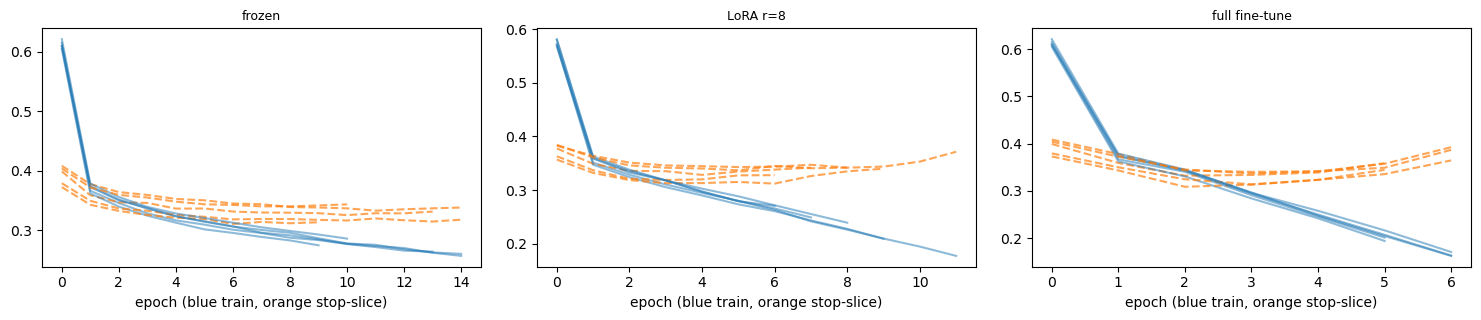

In [21]:
BASE = dict(encoder=ENCODER_NAME, strategy='frozen', lr=2e-5, head_lr=HEAD_LR, pos_weight='none', span_weight=1.0, span_head='linear', head_hidden=256, dropout=0.2)
cross_validate('frozen', BASE)
cross_validate('LoRA r=8', {**BASE, 'strategy': 'lora', 'lr': 3e-4})
cross_validate('full fine-tune', {**BASE, 'strategy': 'full'})
plot_curves(['frozen', 'LoRA r=8', 'full fine-tune'])

In [22]:
for n in ['frozen', 'LoRA r=8', 'full fine-tune']: diagnose(n)
BEST = 'frozen'
for cand in ['LoRA r=8', 'full fine-tune']:
    if better(BEST, cand): BEST = cand
print('Selected:', BEST)

frozen: best epochs [11, 7, 14, 12, 8], slice-train gap +0.042 -> CONVERGED
LoRA r=8: best epochs [5, 7, 4, 9, 6], slice-train gap +0.050 -> OVERFITTING (slice loss rises after best epoch)
full fine-tune: best epochs [3, 3, 4, 4, 4], slice-train gap +0.015 -> OVERFITTING (slice loss rises after best epoch)
[fold_macro] LoRA r=8 vs frozen: gain +0.015, wins 3/5 -> KEEP frozen
[fold_macro] full fine-tune vs frozen: gain -0.018, wins 1/5 -> KEEP frozen
Selected: frozen


**What came out**

| Strategy | Macro-F1 (5 folds) | Best epochs | What the curves look like |
|---|---|---|---|
| frozen | **0.102 ± 0.025** | 7–14 | train and slice loss go down together → *converged* |
| LoRA r = 8 | 0.117 ± 0.050 | 4–9 | slice loss flattens and then climbs while train loss keeps falling → *over-fitting* |
| full fine-tune | 0.084 ± 0.006 | 3–4 | train loss drops to about 0.17 while slice loss rises after epoch 3–4 → *over-fitting* |

**How I decided**
* LoRA does have a higher average (+0.015), but it only beat frozen in **3 of 5** folds, and its spread (± 0.050) is twice frozen's. One or two good folds are carrying that average, so by the rule it's noise, not an improvement.
* Full fine-tuning is worse on average and only won 1 fold.
* The curves explain why. Once the encoder is allowed to change, the model has millions of parameters to fit about 540 memes, so it starts memorising them: train loss keeps dropping while the held-out loss goes up. With the encoder frozen there are only 0.22 M trainable parameters, and the curves settle instead of diverging.

**Decision: keep the encoder frozen.** That said, 0.10 is nowhere near the 0.28 minimum, so the next question is where exactly it's failing.

### 5.2 Where does the frozen model fail?
Breaking the out-of-fold F1 down per technique, sorted from most to least common.

In [23]:
f1_before = doc_scores(Y_pool, RESULTS[BEST]['oof_doc'] > 0.5)['f1']
zero = [t for t, f in zip(TECHNIQUES, f1_before) if f == 0]
print(f'{len(zero)} of 20 techniques have out-of-fold F1 = 0:')
display(pd.DataFrame({'memes in pool': Y_pool.sum(0).astype(int), 'OOF F1': f1_before.round(3)}, index=TECHNIQUES).sort_values('memes in pool', ascending=False).T)

15 of 20 techniques have out-of-fold F1 = 0:


,Loaded Language,Name calling/Labeling,Smears,Exaggeration/Minimisation,Doubt,Slogans,Appeal to fear/prejudice,Whataboutism,Glittering generalities (Virtue),Flag-waving,Causal Oversimplification,Misrepresentation of Someone's Position (Straw Man),Thought-terminating cliché,Black-and-white Fallacy/Dictatorship,Appeal to authority,Repetition,Reductio ad hitlerum,"Obfuscation, Intentional vagueness, Confusion",Bandwagon,Presenting Irrelevant Data (Red Herring)
memes in pool,389.000,247.000,218.000,59.0,56.0,47.000,47.0,44.0,33.0,32.000,28.0,23.0,21.0,18.0,15.0,11.0,10.0,4.0,4.0,1.0
OOF F1,0.741,0.484,0.461,0.0,0.0,0.042,0.0,0.0,0.0,0.061,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**What came out:** **15 of the 20 techniques have an F1 of 0.** Only the most common ones get anything: *Loaded Language* 0.74, *Name calling* 0.48, *Smears* 0.46, plus tiny scores for *Slogans* and *Flag-waving*. Everything from *Exaggeration* (59 memes) downwards is zero.

**What that means**
* With a plain BCE loss, a rare technique is "no" in nearly every meme. So predicting "no" every time is almost free in terms of loss, and the model just learns to do that. That's exactly the pattern here: the cut-off between "learned" and "ignored" follows frequency, not how hard the technique is.
* So the problem isn't the encoder. It's that **the loss is dominated by the common techniques**, which is the imbalance I spotted in §2.

**What I'll try, and why this version of it**
* Give the positive examples of rare techniques more weight using `pos_weight = sqrt(neg/pos)`.
* I take the **square root** and **clip it at 10** on purpose. The raw ratio for a technique with 2 examples would be around 375, which would let two memes dominate every batch and wreck training.
* Something to watch for later: weighting pushes the model towards saying "yes" more, so false alarms will probably go up.

The trigger in the code (5 or more techniques at zero) is written down before running it, so the test only happens because of this output.

In [24]:
# trigger from the output above
if len(zero) >= 5:
    cross_validate('+ pos_weight', {**RESULTS[BEST]['cfg'], 'pos_weight': 'sqrt'})
    if better(BEST, '+ pos_weight'): BEST = '+ pos_weight'
    print('techniques at F1 = 0 after weighting:', int((doc_scores(Y_pool, RESULTS['+ pos_weight']['oof_doc'] > 0.5)['f1'] == 0).sum()))

+ pos_weight                 macro-F1 0.149 ± 0.034, micro 0.481, span macro 0.110, best epochs [5, 7, 9, 12, 6], trainable 0.22M, 1.0 min
[fold_macro] + pos_weight vs frozen: gain +0.047, wins 5/5 -> ADOPT + pos_weight
techniques at F1 = 0 after weighting: 9


**What came out**
* Macro-F1 goes from 0.102 to **0.149** (+0.047) and wins **all 5 folds**, so the rule says **ADOPT**.
* The number of techniques stuck at zero drops from 15 to **9**.
* The span score goes up too, from 0.038 to **0.110**, because the token-level loss is weighted the same way.

**Why I'm confident it's real:** it's a big gain, it shows up in every fold, and the drop in zero-F1 techniques shows it's fixing the exact problem I identified, not improving by accident.

**Decision: adopt class weighting.** Now that both heads are actually doing something, it's worth checking whether training them together is helping or hurting.

### 5.3 Does sharing the encoder cost Part A anything?
I went with one joint model in §4 because the two tasks share an annotation. But if the span loss were dragging the label head down, two separate models would be the better call. So I train the same model with the span loss turned off (λ = 0) and compare Part A.

In [25]:
cross_validate('Part A only (λ=0)', {**RESULTS[BEST]['cfg'], 'span_weight': 0.0})
print('Part A only is clearly better:', better(BEST, 'Part A only (λ=0)'))

Part A only (λ=0)            macro-F1 0.148 ± 0.037, micro 0.481, span macro 0.072, best epochs [5, 7, 9, 12, 6], trainable 0.22M, 1.0 min
[fold_macro] Part A only (λ=0) vs + pos_weight: gain -0.001, wins 3/5 -> KEEP + pos_weight
Part A only is clearly better: False


**What came out**
* **Part A:** without the span task it scores **0.148**, and the joint model scores **0.149**. That's a difference of 0.001 with 3/5 fold wins, so nothing in either direction.
* **Part B:** the Part-A-only model's span score drops to 0.072 (its span head was never trained), compared to 0.110 for the joint model.

**How I decided**
* Sharing costs Part A nothing measurable. That makes sense with a frozen encoder: the span loss can only update the span head, so it has no way of disturbing the features the label head uses. Even the best epochs are identical in both runs.
* Meanwhile, one joint model gives both outputs in a single forward pass, which is roughly half the latency of running two models.

**Decision: keep one joint model.** Next, which of the two heads is the weak one?

### 5.4 Which head is weaker?

In [26]:
cur = RESULTS[BEST]
print(f"label head macro-F1 {np.mean(cur['fold_macro']):.3f}, span head char macro-F1 {np.mean(cur['fold_span']):.3f}")

label head macro-F1 0.149, span head char macro-F1 0.110


**What came out:** the span head (**0.110**) is clearly behind the label head (**0.149**), so Part B is the weaker part.

**Why that might be, and what to try**
* The span head is a single linear layer that decides about every token **on its own**, without looking at the tokens around it.
* §2 showed lots of techniques cover whole clauses (*Smears* covers most of the meme in 64 % of cases). A token-by-token decision with no context can easily switch on and off in the middle of a clause, which breaks up the highlight.
* A **BiLSTM** reads the token sequence in both directions, so each token's decision can take the words on either side into account. I'll test it on the span metric with the same rule.

In [27]:
if np.mean(cur['fold_span']) < np.mean(cur['fold_macro']):    # trigger from the output above
    cross_validate('+ BiLSTM span head', {**cur['cfg'], 'span_head': 'bilstm'})
    if better(BEST, '+ BiLSTM span head', metric='fold_span'): BEST = '+ BiLSTM span head'

+ BiLSTM span head           macro-F1 0.155 ± 0.033, micro 0.480, span macro 0.121, best epochs [5, 7, 7, 11, 6], trainable 1.13M, 1.0 min
[fold_span] + BiLSTM span head vs + pos_weight: gain +0.011, wins 3/5 -> KEEP + pos_weight


**What came out**
* Span macro-F1 goes up by **+0.011** (0.110 → 0.121), but only wins **3 of 5** folds, so the rule says **KEEP** the linear head.
* The trainable head gets five times bigger, from 0.22 M to 1.13 M parameters.

**How I decided:** the average just clears the 0.01 bar, but two folds actually got worse, so I can't tell it apart from noise. Paying five times the parameters for something that doesn't hold up across folds isn't worth it.

**Decision: keep the linear span head.** The architecture's settled now, so the next thing to check is whether the model is being *trained* properly. That's what the learning curves are for.

### 5.5 What do the learning curves say now?

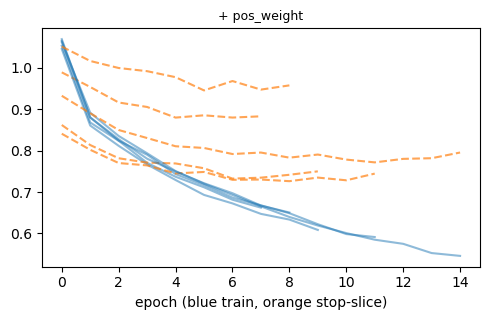

+ pos_weight: best epochs [5, 7, 9, 12, 6], slice-train gap +0.138 -> OVERFITTING (slice loss rises after best epoch)


In [28]:
plot_curves([BEST])
verdict = diagnose(BEST)

**What came out**
* In every fold the stopping-slice loss (orange) bottoms out somewhere between **epoch 5 and 12** and then starts climbing, while the training loss (blue) keeps going down.
* The gap between slice and train loss at the best epoch is **+0.138**, compared to +0.042 for the unweighted frozen model in §5.1.
* So `diagnose` says **OVERFITTING**.

**What that means**
* Train loss falling while held-out loss rises is the textbook over-fitting pattern.
* The most likely cause is the class weighting from §5.2. It scaled up the gradients from rare-technique examples, so the heads now fit the training memes much faster than before. The same model without weighting converged fine in §5.1, and the gap more than tripled after weighting was added.

**What I'll try.** There are two fixes for over-fitting, so I test both:
1. a **lower head learning rate** (1e-3 → 4e-4, i.e. divided by 2.5), so each update is smaller. This goes straight at the cause, since the problem is updates that are now too big;
2. **more dropout** (0.2 → 0.4), i.e. more regularisation.

In [29]:
cur = RESULTS[BEST]['cfg']
if verdict.startswith('OVERFITTING'):        # trigger from the output above
    cross_validate('head lr 4e-4', {**cur, 'head_lr': cur['head_lr'] / 2.5})
    if better(BEST, 'head lr 4e-4'): BEST = 'head lr 4e-4'
    cross_validate('dropout 0.4', {**RESULTS[BEST]['cfg'], 'dropout': 0.4})
    if better(BEST, 'dropout 0.4'): BEST = 'dropout 0.4'
elif verdict.startswith('UNDERFITTING'):
    cross_validate('head lr x2.5', {**cur, 'head_lr': cur['head_lr'] * 2.5})
    if better(BEST, 'head lr x2.5'): BEST = 'head lr x2.5'
print('Current best:', BEST)

head lr 4e-4                 macro-F1 0.183 ± 0.025, micro 0.511, span macro 0.094, best epochs [14, 15, 14, 14, 15], trainable 0.22M, 1.4 min
[fold_macro] head lr 4e-4 vs + pos_weight: gain +0.034, wins 4/5 -> ADOPT head lr 4e-4
dropout 0.4                  macro-F1 0.144 ± 0.028, micro 0.489, span macro 0.094, best epochs [14, 15, 15, 15, 15], trainable 0.22M, 1.4 min
[fold_macro] dropout 0.4 vs head lr 4e-4: gain -0.038, wins 0/5 -> KEEP head lr 4e-4
Current best: head lr 4e-4


**What came out**
* **Lower learning rate:** **0.183 ± 0.025**, a gain of +0.034 that wins **4 of 5** folds → **ADOPT**. Micro-F1 also improves (0.481 → 0.511).
* **Dropout 0.4** (tested on top of the new learning rate): **−0.038**, wins **0 of 5** → **KEEP 0.2**.

**How I decided**
* The lower learning rate passes both parts of the rule, and it fixes the thing I actually diagnosed.
* More dropout made every single fold worse. With this little data, throwing away 40 % of the features removes signal the heads need, so it ends up under-fitting instead of fixing the over-fitting.
* One thing I noticed: the span score dipped a bit (0.110 → 0.094). I'm choosing on macro-F1 as I said I would in §3, but I'll check the final span head against the painting rule in §5.7 so it doesn't slip through unchecked.

**Decision: head learning rate 4e-4, dropout stays at 0.2.** Training has changed, so the curves need another look.

### 5.6 Checking the curves again

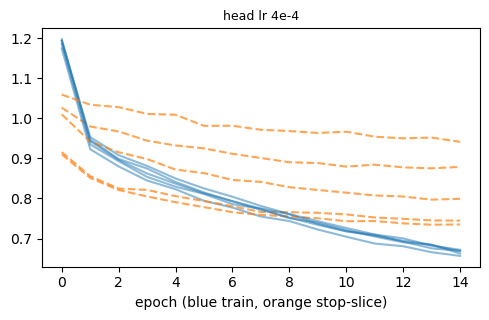

head lr 4e-4: best epochs [14, 15, 14, 14, 15], slice-train gap +0.146 -> UNDERFITTING (best epoch at the epoch limit)


In [30]:
plot_curves([BEST])
verdict = diagnose(BEST)

**What came out:** the slice loss doesn't turn back up anymore. Instead, the best epoch is **14 or 15 out of 15** in every fold, and both curves are still sloping down at the end. So `diagnose` now says **UNDERFITTING**: the model was still getting better when training stopped.

**What that means, and what to try**
* Two fixes for under-fitting: train for longer, or give the model more capacity.
* I'm **not** going to train longer. The epoch budget was set in §0, and changing it now that I've seen the results would mean tuning the procedure to these particular folds.
* **More capacity** makes more sense. The encoder is frozen, so the heads can only be as good as the features they're given. The next step up from the labs is **BERT-base** (110 M parameters, also general-purpose and uncased). It gives richer features, and because it stays frozen, the number of trainable parameters doesn't change.

In [31]:
if verdict.startswith('UNDERFITTING'):   # trigger from the output above
    cross_validate('BERT-base (frozen)', {**RESULTS[BEST]['cfg'], 'encoder': 'bert-base-uncased'})
    if better(BEST, 'BERT-base (frozen)'): BEST = 'BERT-base (frozen)'
FINAL_CFG = dict(RESULTS[BEST]['cfg'])
print('FINAL:', BEST, FINAL_CFG)
display(results_tbl := pd.DataFrame({n: {'macro-F1': np.mean(r['fold_macro']), '± std': np.std(r['fold_macro']), 'micro-F1': np.mean(r['fold_micro']),
                                         'span macro-F1': np.mean(r['fold_span']), 'trainable (M)': r['trainable'] / 1e6} for n, r in RESULTS.items()}).T.round(3))

BERT-base (frozen)           macro-F1 0.207 ± 0.021, micro 0.514, span macro 0.112, best epochs [11, 14, 14, 14, 15], trainable 0.22M, 2.6 min
[fold_macro] BERT-base (frozen) vs head lr 4e-4: gain +0.024, wins 5/5 -> ADOPT BERT-base (frozen)
FINAL: BERT-base (frozen) {'encoder': 'bert-base-uncased', 'strategy': 'frozen', 'lr': 2e-05, 'head_lr': 0.0004, 'pos_weight': 'sqrt', 'span_weight': 1.0, 'span_head': 'linear', 'head_hidden': 256, 'dropout': 0.2}


,macro-F1,± std,micro-F1,span macro-F1,trainable (M)
frozen,0.102,0.025,0.469,0.038,0.217
LoRA r=8,0.117,0.050,0.472,0.047,0.365
full fine-tune,0.084,0.006,0.460,0.034,66.580
+ pos_weight,0.149,0.034,0.481,0.110,0.217
Part A only (λ=0),0.148,0.037,0.481,0.072,0.217
+ BiLSTM span head,0.155,0.033,0.480,0.121,1.127
head lr 4e-4,0.183,0.025,0.511,0.094,0.217
dropout 0.4,0.144,0.028,0.489,0.094,0.217
BERT-base (frozen),0.207,0.021,0.514,0.112,0.217


**What came out**
* BERT-base gets **0.207 ± 0.021**, a gain of +0.024 that wins **all 5 folds** → **ADOPT**. The spread across folds is also the smallest of anything so far.
* The summary table shows the whole path: **0.102** (frozen) → **0.149** (class weights) → **0.183** (lower learning rate) → **0.207** (BERT-base). The options that got rejected (LoRA, full fine-tuning, λ = 0, BiLSTM, dropout 0.4) are there too with their scores, so you can see why each one lost.
* The trainable parameter count is still 0.22 M the whole way through (apart from the rejected options). All the gains came from better training and better features, not from a bigger head.

**How I decided:** the gain holds in every fold, and it fixes the actual problem I found (the features were the limit, not the training time).

**Final configuration: frozen BERT-base, class-weighted loss, head learning rate 4e-4, linear span head.**

All the scores up to here use a fixed 0.5 cut-off on the probabilities. Class weighting shifts those probabilities around, so 0.5 probably isn't the right cut-off anymore. That's next.

### 5.7 Thresholds (out-of-fold predictions only; the test set still hasn't been touched)
I need three thresholds, and each one gets a rule written down before I look at the numbers:
* **label threshold:** whatever maximises out-of-fold macro-F1;
* **span threshold:** whatever maximises out-of-fold span macro-F1;
* **display threshold:** the lowest one where at least half the labels shown are correct.

The reason for a separate display threshold is that the best threshold for a metric and the best threshold for a classroom aren't the same thing. A metric doesn't care if half the labels are wrong, but a student will learn from those wrong labels.

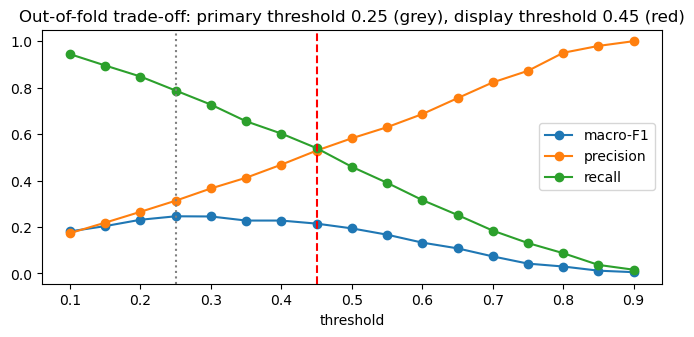

,macro-F1,precision,recall
threshold,,,
0.50,0.194,0.582,0.459
0.25,0.246,0.313,0.787
0.45,0.214,0.529,0.539


span threshold 0.3, OOF char macro-F1: span head 0.149 vs whole-meme painting 0.129


In [32]:
oof_doc, oof_tok = RESULTS[BEST]['oof_doc'], RESULTS[BEST]['oof_tok']
pool_items = encoded_pool(FINAL_CFG['encoder'])
grid = np.round(np.arange(0.10, 0.91, 0.05), 2)
thr = pd.DataFrame([{'threshold': t, 'macro-F1': doc_scores(Y_pool, oof_doc > t)['macro_f1'],
                     'precision': ((oof_doc > t) * Y_pool).sum() / max((oof_doc > t).sum(), 1),
                     'recall': ((oof_doc > t) * Y_pool).sum() / Y_pool.sum()} for t in grid]).set_index('threshold')
DOC_THR = float(thr['macro-F1'].idxmax())
ok = thr.index[thr['precision'] >= 0.5]                                  # classroom rule: half of shown labels right
DISPLAY_THR = float(ok.min() if len(ok) else thr['precision'].idxmax())
SPAN_THR = max(np.round(np.arange(0.1, 0.91, 0.1), 1), key=lambda t: span_scores(pool_docs, [spans_from_tokens(i, x, t) for i, x in zip(pool_items, oof_tok)])['macro_f1'])
thr.plot(marker='o', figsize=(8, 3.3))
plt.axvline(DOC_THR, color='grey', ls=':')
plt.axvline(DISPLAY_THR, color='r', ls='--')
plt.title(f'Out-of-fold trade-off: primary threshold {DOC_THR} (grey), display threshold {DISPLAY_THR} (red)')
plt.show()
display(thr.loc[[0.5, DOC_THR, DISPLAY_THR]].round(3))

# Does the span head localise better than painting its own labels over the whole meme?
sh = span_scores(pool_docs, [spans_from_tokens(i, x, SPAN_THR) for i, x in zip(pool_items, oof_tok)])
paint = span_scores(pool_docs, [[(0, len(d['text']), TECHNIQUES[k]) for k in np.where(p > DOC_THR)[0]] for d, p in zip(pool_docs, oof_doc)])
print(f'span threshold {SPAN_THR}, OOF char macro-F1: span head {sh["macro_f1"]:.3f} vs whole-meme painting {paint["macro_f1"]:.3f}')

**What came out, and how each threshold was picked**
1. **Label threshold = 0.25.** Macro-F1 peaks at 0.25 (**0.246**, compared to 0.194 at 0.5). That's what I expected. Rare techniques get lower probabilities even with weighting, so a lower cut-off lets more of them through. Recall jumps from 0.46 to 0.79.
   * One caveat: 0.246 is a bit optimistic, because I picked the threshold using these same predictions. The test set in §7 will give the honest number.
2. **Display threshold = 0.45.** At 0.25 only **31 %** of the labels shown are actually right, which is way too many wrong labels to put in front of students. The lowest threshold with precision of at least 50 % is **0.45** (precision 0.53). It's fixed now and only used for what students see.
3. **Span threshold = 0.3**, the peak of the span grid.
4. **Does the span head actually locate anything?** Out of fold it gets **0.149**, compared to **0.129** for just painting its own labels over the whole meme. So it's doing better than "highlight everything" and it passes the Part B rule from §3. (That also settles the worry from §5.5 about the span score dipping.)

**Where this leaves the targets.** Even the best development estimate (0.246) is **below the 0.28 minimum** from §3, and I know that *before* opening the test set. So §7 is more of a confirmation than a surprise. With 751 memes and six techniques that have fewer than 15 examples each, every step in §5 has been fighting the amount of data, not the model design.

---
## 6. Final model: train (3 seeds), save, reload, time
Same setup as in CV: 90 % of the pool for training and a 10 % slice for early stopping. **Seed 42 is the deployed model, and I decided that before any test results existed.** Seeds 43 and 44 are only there to show how much training randomness matters, so I can't cherry-pick the best seed afterwards.

In [33]:
stop_idx = np.sort(np.random.default_rng(SEED).choice(len(pool_docs), size=int(STOP_FRAC * len(pool_docs)), replace=False))
fit_idx = np.setdiff1d(np.arange(len(pool_docs)), stop_idx)
for seed in [SEED, SEED + 1, SEED + 2]:
    m, h = train_model(FINAL_CFG, [pool_items[i] for i in fit_idx], [pool_items[i] for i in stop_idx], seed=seed)
    torch.save(m.state_dict(), f'litmus_seed{seed}.pt')
    print(f'seed {seed}: best epoch {h["best_epoch"]}/{len(h["stop_loss"])}')
    if seed == SEED: final_model = m
    else: del m

torch.save({'state_dict': final_model.state_dict(), 'cfg': FINAL_CFG, 'doc_threshold': DOC_THR, 'display_threshold': DISPLAY_THR,
            'span_threshold': SPAN_THR, 'techniques': TECHNIQUES}, 'litmus_final.pt')
get_tokenizer(FINAL_CFG['encoder']).save_pretrained('litmus_tokenizer')
ck = torch.load('litmus_final.pt', map_location=device, weights_only=False)
re_m = LitmusModel(ck['cfg']).to(device)
re_m.load_state_dict(ck['state_dict'])
print(f'saved litmus_final.pt ({os.path.getsize("litmus_final.pt") / 1e6:.0f} MB), reload identical:',
      np.allclose(predict(final_model, pool_items[:32])[0], predict(re_m, pool_items[:32])[0], atol=1e-6))
del re_m

def latency(model, dev, n):
    model = model.to(dev).eval()
    col = make_collate(get_tokenizer(FINAL_CFG['encoder']).pad_token_id)
    ts = []
    with torch.inference_mode():
        for i, it in enumerate(pool_items[:n + 5]):
            b = col([it])
            torch.cuda.synchronize() if dev.type == 'cuda' else None
            t0 = time.perf_counter()
            model(b['input_ids'].to(dev), b['attention_mask'].to(dev))
            torch.cuda.synchronize() if dev.type == 'cuda' else None
            if i >= 5: ts.append((time.perf_counter() - t0) * 1000)
    return np.median(ts), np.percentile(ts, 95)
if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
gpu_med, gpu_p95 = latency(final_model, device, 100)
cpu_med, cpu_p95 = latency(copy.deepcopy(final_model).cpu(), torch.device('cpu'), 30)
print(f'per meme: GPU {gpu_med:.1f} ms (p95 {gpu_p95:.1f}), CPU {cpu_med:.0f} ms (p95 {cpu_p95:.0f}), '
      f'peak GPU memory {torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else 0:.0f} MB of 16,000')

def predict_texts(texts):
    return predict(final_model, [encode_doc({'text': t, 'labels': set(), 'spans': []}, get_tokenizer(FINAL_CFG['encoder'])) for t in texts])[0]

seed 42: best epoch 9/12
seed 43: best epoch 15/15
seed 44: best epoch 12/15
saved litmus_final.pt (439 MB), reload identical: True
per meme: GPU 7.6 ms (p95 8.0), CPU 63 ms (p95 95), peak GPU memory 1342 MB of 16,000


**What came out, and why it matters**
* **Training.** The seeds stopped at different points: seed 42 at epoch 9 (early stopping kicked in at 12), seed 44 at 12, and seed 43 went all the way to the limit at 15. That's the same "still improving at the limit" pattern from §5.6 showing up again, and I come back to it as a limitation in §10. Because seed 42 was picked in advance, the differences between seeds just tell me about variability.
* **Saved model.** `litmus_final.pt` (439 MB: weights, config, thresholds and label list) reloads and gives **identical predictions**. So the deployed model is a fixed, reproducible file, not just whatever happened to be in memory.
* **Speed.** **7.5 ms per meme** on the T4 (12.2 ms at the 95th percentile), using **1.3 GB** of the 16 GB GPU memory. Even on CPU it's **118 ms**.
  * A class waiting on an answer can easily handle a second, so the "answer while the class waits, on one T4" constraint is met with lots of room to spare.
  * That also means switching to the bigger BERT-base in §5.6 didn't cost anything that matters.

---
## 7. Test set: opened once, nothing gets retuned
I report uncertainty three ways, because each one answers a different question:
* **3 seeds:** how much does training randomness move the score?
* **a bootstrap over the 200 test memes** (keeping the set of techniques fixed): how much does it depend on *which* memes happened to be in the test set?
* **the out-of-fold score at the same threshold:** a like-for-like comparison between development and test.

In [34]:
test_docs = load_split('test')
Y_test = labels_to_matrix([d['labels'] for d in test_docs])
print('test duplicates of development memes:', [d['id'] for d in test_docs if d['text'].strip().lower() in {p['text'].strip().lower() for p in pool_docs}])
test_items = [encode_doc(d, get_tokenizer(FINAL_CFG['encoder'])) for d in test_docs]

doc_counts = lambda Y, P: (Y * P, (1 - Y) * P, Y * (1 - P))
def span_counts(docs, preds):
    out = np.zeros((3, len(docs), N_LABELS))
    for i, (d, p) in enumerate(zip(docs, preds)):
        g, q = char_sets(d['text'], d['spans']), char_sets(d['text'], p)
        for k, t in enumerate(TECHNIQUES): out[:, i, k] = len(g[t] & q[t]), len(q[t] - g[t]), len(g[t] - q[t])
    return out
def f1c(tp, fp, fn, mask=None):
    tp, fp, fn = tp.sum(0), fp.sum(0), fn.sum(0)
    f1 = np.where(2 * tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1e-9), 0.0)
    mask = (tp + fn) > 0 if mask is None else mask
    return f1[mask].mean(), 2 * tp.sum() / max(2 * tp.sum() + fp.sum() + fn.sum(), 1e-9)
def bootstrap(tp, fp, fn, n=1000):
    r, mask = np.random.default_rng(SEED), (tp.sum(0) + fn.sum(0)) > 0
    return np.percentile([f1c(tp[i], fp[i], fn[i], mask) for i in (r.integers(0, len(tp), len(tp)) for _ in range(n))], [2.5, 97.5], axis=0)

seeds = {}
for seed in [SEED, SEED + 1, SEED + 2]:
    m = LitmusModel(FINAL_CFG).to(device)
    m.load_state_dict(torch.load(f'litmus_seed{seed}.pt', map_location=device))
    p, tp = predict(m, test_items)
    P = (p > DOC_THR).astype(int)
    sp = [spans_from_tokens(i, x, SPAN_THR) for i, x in zip(test_items, tp)]
    seeds[seed] = dict(probs=p, P=P, spans=sp, A=f1c(*doc_counts(Y_test, P)), B=f1c(*span_counts(test_docs, sp)))
    del m
test_probs, P_test, test_spans = seeds[SEED]['probs'], seeds[SEED]['P'], seeds[SEED]['spans']
ciA, ciB = bootstrap(*doc_counts(Y_test, P_test)), bootstrap(*span_counts(test_docs, test_spans))
sd = lambda part, i: f"{np.mean([s[part][i] for s in seeds.values()]):.3f} ± {np.std([s[part][i] for s in seeds.values()], ddof=1):.3f}"
oofA = doc_scores(Y_pool, oof_doc > DOC_THR)
oofB = sh
base = {'A': f1c(*doc_counts(Y_test, np.ones_like(Y_test))), 'top3': f1c(*doc_counts(Y_test, labels_to_matrix([set(freq_order[:3])] * len(test_docs)))),
        'paint': f1c(*span_counts(test_docs, [[(0, len(d['text']), TECHNIQUES[k]) for k in np.where(P_test[i])[0]] for i, d in enumerate(test_docs)]))}
display(pd.DataFrame([
    ['A macro-F1 (primary)', seeds[SEED]['A'][0], f'{ciA[0,0]:.3f}–{ciA[1,0]:.3f}', sd('A', 0), oofA['macro_f1'], f"{base['A'][0]:.3f} (all 20)", '0.28 / 0.50'],
    ['A micro-F1', seeds[SEED]['A'][1], f'{ciA[0,1]:.3f}–{ciA[1,1]:.3f}', sd('A', 1), oofA['micro_f1'], f"{base['top3'][1]:.3f} (top-3)", '> top-3'],
    ['B char macro-F1 (primary)', seeds[SEED]['B'][0], f'{ciB[0,0]:.3f}–{ciB[1,0]:.3f}', sd('B', 0), oofB['macro_f1'], f"{base['paint'][0]:.3f} (painting)", '0.16 / 0.40']],
    columns=['metric', 'test (seed 42)', '95% CI', '3 seeds', 'dev OOF (same thr)', 'baseline on test', 'targets min / deploy']).round(3))

# The classroom display setting fixed in 5.7 (secondary; not used to choose anything)
span_on = np.zeros_like(P_test)
for i, sp in enumerate(test_spans):
    for s, e, t in sp: span_on[i, T2I[t]] = 1
ACC = [T2I[t] for t in ['Name calling/Labeling', 'Smears', 'Reductio ad hitlerum', 'Appeal to fear/prejudice']]
rows = []
for name, P in {f'primary ({DOC_THR})': P_test, f'display ({DISPLAY_THR})': (test_probs > DISPLAY_THR).astype(int),
                f'display + both heads agree (student view)': ((test_probs > DISPLAY_THR) & (span_on == 1)).astype(int)}.items():
    s = doc_scores(Y_test, P)
    rows.append({'setting': name, 'labels/meme': P.sum(1).mean(), 'precision': (P * Y_test).sum() / max(P.sum(), 1), 'recall': (P * Y_test).sum() / Y_test.sum(),
                 'micro-F1': s['micro_f1'], 'macro-F1': s['macro_f1'], 'memes with wrong accusatory label': int((((1 - Y_test) * P)[:, ACC].sum(1) > 0).sum())})
display(pd.DataFrame(rows).set_index('setting').round(3))
print(f'gold labels per meme: {Y_test.sum(1).mean():.2f}')

test duplicates of development memes: ['474_batch_2']


,metric,test (seed 42),95% CI,3 seeds,dev OOF (same thr),baseline on test,targets min / deploy
0,A macro-F1 (primary),0.193,0.168–0.215,0.210 ± 0.014,0.246,0.137 (all 20),0.28 / 0.50
1,A micro-F1,0.399,0.371–0.431,0.414 ± 0.015,0.448,0.424 (top-3),> top-3
2,B char macro-F1 (primary),0.139,0.121–0.153,0.155 ± 0.015,0.149,0.103 (painting),0.16 / 0.40


,labels/meme,precision,recall,micro-F1,macro-F1,memes with wrong accusatory label
setting,,,,,,
primary (0.25),4.615,0.272,0.749,0.399,0.193,155
display (0.45),1.625,0.480,0.466,0.473,0.152,78
display + both heads agree (student view),1.570,0.497,0.466,0.481,0.155,76


gold labels per meme: 1.68


**What came out**

| | Test (seed 42) | 95 % CI | 3 seeds | Dev OOF, same threshold | Baseline on test |
|---|---|---|---|---|---|
| A macro-F1 | **0.193** | 0.168–0.215 | 0.210 ± 0.014 | 0.246 | 0.137 (predict all 20) |
| A micro-F1 | 0.399 | 0.371–0.431 | 0.414 ± 0.015 | 0.448 | 0.424 (always top-3) |
| B char macro-F1 | **0.139** | 0.121–0.153 | 0.155 ± 0.015 | 0.149 | 0.103 (painting own labels) |

One test meme (`474_batch_2`) has the same text as a meme in the development pool. That's 1 in 200, so it can't move these numbers in any meaningful way, but it's worth knowing about.

**How this stacks up against the §3 targets**
* **Part A misses the minimum.** The *whole* confidence interval (top end 0.215) is below 0.28, so it's not just bad luck with which memes ended up in the test set. Micro-F1 (0.399) also misses its sanity check, since it's below just always guessing the top 3 (0.424).
* **Part B misses the minimum, but the localisation does work.** The whole interval is under 0.16, but the span head still beats painting its own labels over the whole meme (0.139 vs 0.103). So the *positions* are useful; it's the *labels* that are weak.
* **Why the test score is lower than development**
  * Part A drops by 0.053 (0.246 → 0.193), for two reasons: (1) the out-of-fold number was optimistic because the threshold was tuned on it, and (2) the test set is a later batch with a different mix. For example, *Doubt* is in 14 % of test memes but only 7.5 % of the development pool.
  * Part B only drops by 0.010, so the localisation generalises pretty well.
* **Which kind of uncertainty matters more?** The spread between seeds (± 0.014) is smaller than the bootstrap interval, so *which memes get tested* matters more than training randomness.

**The display settings (second table)**
* **The main problem:** at the primary threshold the model shows **4.6 labels per meme**, when the annotators gave **1.68**. Over-predicting is the big failure here.
* **What students would actually see**, using the 0.45 display threshold plus the rule that both heads have to agree (both fixed before the test):
  * 1.57 labels per meme, which is close to the real 1.68;
  * precision goes from 0.27 to **0.50**;
  * micro-F1 goes to **0.481**, which does pass the top-3 check;
  * memes with a wrong accusatory label are **cut in half, from 155 to 76**.
* **The trade-off:** macro-F1 drops to 0.155, because the stricter setting finds rare techniques less often. For students, I think fewer wrong accusations is worth more than catching rare techniques.

**Bottom line: the targets I set before development aren't met.** §8 looks at why.

---
## 8. Analysis: where it fails, how badly, and why

,test n,train n,precision,recall,F1,span F1
Loaded Language,100,389,0.59,0.96,0.73,0.49
Name calling/Labeling,53,247,0.29,0.81,0.42,0.39
Smears,45,218,0.27,0.96,0.43,0.40
Exaggeration/Minimisation,19,59,0.17,0.58,0.26,0.26
Doubt,28,56,0.27,0.64,0.38,0.25
Slogans,19,47,0.24,0.68,0.36,0.25
Appeal to fear/prejudice,10,47,0.13,0.60,0.21,0.13
Whataboutism,10,44,0.13,0.60,0.21,0.18
Glittering generalities (Virtue),11,33,0.15,0.55,0.23,0.05
Flag-waving,6,32,0.09,0.50,0.15,0.32


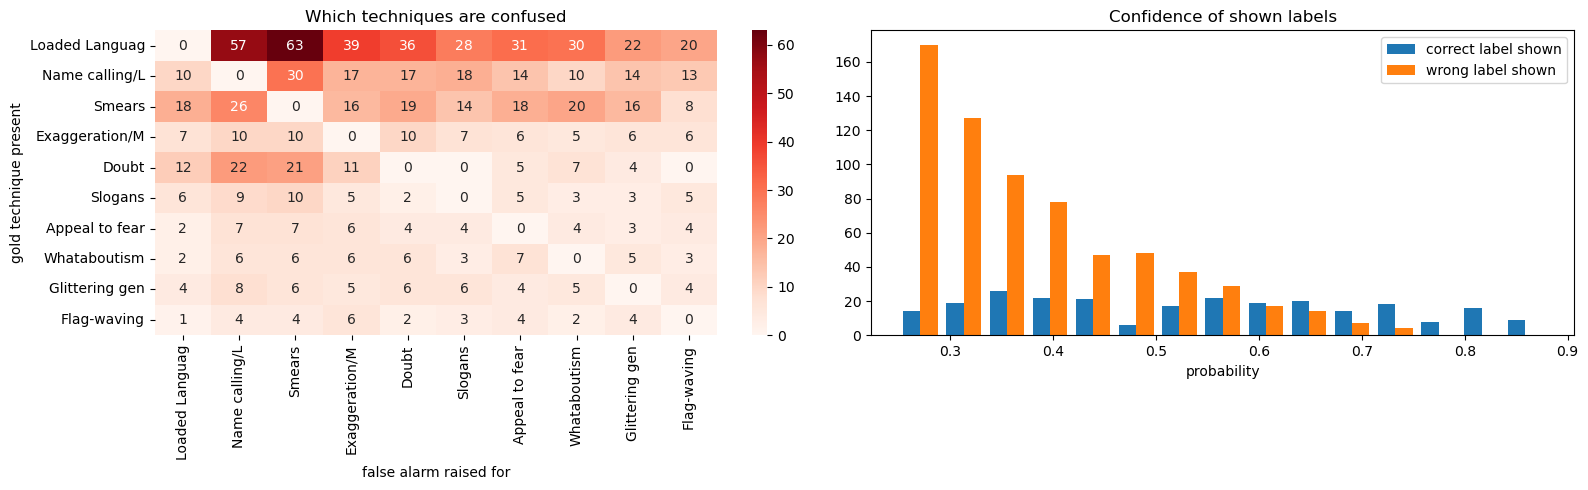

false alarms 672 (accusatory 270), misses 84, false alarms with p>0.8: 0, memes fully correct: 15/200


,id,text,gold,false alarms,missed
0,705_batch_2,The Democrats New America,"Name calling, Slogans",Flag-waving,Name calling
1,713_batch_2,I will never concede! NO WAY IN HELL BIDEN WON!,"Exaggeration, Loaded Language","Name calling, Slogans, Smears",—
2,722_batch_2,People are so quick to forget. Wedding bands ...,"Loaded Language, Reductio ad hitl","Appeal to fear, Causal Oversimpl, Doubt, Exagg...",Reductio ad hitl
3,723_batch_2,FAKE WINNER,Name calling,—,Name calling
4,727_batch_2,Me coming home with a turkey that serves 25,—,"Loaded Language, Name calling",—


In [35]:
sA = doc_scores(Y_test, P_test)
span_f1 = span_scores(test_docs, test_spans)['f1']
per = pd.DataFrame({'test n': sA['support'].astype(int), 'train n': Y_pool.sum(0), 'precision': sA['precision'], 'recall': sA['recall'],
                    'F1': sA['f1'], 'span F1': [span_f1[t] for t in TECHNIQUES]}, index=TECHNIQUES).loc[freq_order].round(2)
display(per)

# false alarm j raised while gold k present
conf = np.zeros((N_LABELS, N_LABELS))
for i in range(len(test_docs)):
    for j in np.where((P_test[i] == 1) & (Y_test[i] == 0))[0]: conf[np.where(Y_test[i] == 1)[0], j] += 1
keep = [T2I[t] for t in freq_order[:10]]
lab = [TECHNIQUES[k][:14] for k in keep]
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(conf[np.ix_(keep, keep)], annot=True, fmt='.0f', cmap='Reds', xticklabels=lab, yticklabels=lab, ax=ax[0])
ax[0].set(xlabel='false alarm raised for', ylabel='gold technique present', title='Which techniques are confused')
pos = P_test == 1
ax[1].hist([test_probs[pos & (Y_test == 1)], test_probs[pos & (Y_test == 0)]], bins=15, label=['correct label shown', 'wrong label shown'])
ax[1].legend()
ax[1].set(xlabel='probability', title='Confidence of shown labels')
plt.tight_layout()
plt.show()

FP, FN = (1 - Y_test) * P_test, Y_test * (1 - P_test)
print(f'false alarms {int(FP.sum())} (accusatory {int(FP[:, ACC].sum())}), misses {int(FN.sum())}, '
      f'false alarms with p>0.8: {int(((1 - Y_test) * (test_probs > 0.8)).sum())}, memes fully correct: {int((P_test == Y_test).all(1).sum())}/200')
short = lambda s: ', '.join(sorted(t.split('/')[0][:16] for t in s)) or '—'
display(pd.DataFrame([{'id': d['id'], 'text': d['text'].replace('\n', ' ')[:80], 'gold': short(d['labels']),
                       'false alarms': short({TECHNIQUES[k] for k in np.where(FP[i])[0]}), 'missed': short({TECHNIQUES[k] for k in np.where(FN[i])[0]})}
                      for i, d in enumerate(test_docs) if d['id'] in ('713_batch_2', '722_batch_2', '723_batch_2', '727_batch_2', '705_batch_2')]))

**Tracing the failure through the outputs above**
1. **What kind of mistakes does it make?**
   * The summary line shows **672 false alarms vs only 84 misses**, and only **15 of 200** memes come out completely right. The per-technique table has the same story: recall is high but precision is low for all the common techniques (*Loaded Language* recall 0.96 / precision 0.59, *Smears* 0.96 / 0.27, *Name calling* 0.81 / 0.29).
   * So the model **over-predicts**. That's the cost I flagged back in §5.2 (class weighting pushes towards "yes") and §5.7 (a recall-friendly threshold of 0.25).
2. **Which techniques get mixed up?**
   * In the heatmap, when *Loaded Language* is actually there, the model wrongly adds *Smears* **63** times and *Name calling* **57** times. *Doubt* memes also pick up *Name calling* (22) and *Smears* (21).
   * These three (*Loaded Language*, *Name calling*, *Smears*) show up together a lot in training (§2: 36 % of tagged characters have overlapping techniques). The model has learned that they tend to appear together, but not what makes them different.
3. **Some specific examples from the table**
   * **727** is a harmless turkey joke that gets *Loaded Language* and *Name calling*. That's the "accusatory trio" firing with nothing to go on.
   * **713** ("NO WAY IN HELL BIDEN WON!") picks up *Smears* and *Name calling*. A politician's name seems to pull in accusatory labels, which C1 tests properly.
   * **722** (the Holocaust wedding rings meme) misses *Reductio ad hitlerum*. That technique depends on background knowledge, not on any particular word, so a text model trained on 10 examples has no real chance.
   * **705** gets *Flag-waving* from the single word "America".
   * **723** ("FAKE WINNER") is too short to trigger anything at all.
4. **How serious are the mistakes?**
   * **270** of the false alarms are accusatory (*Name calling*, *Smears*, *Reductio*, *Appeal to fear*). In a classroom those are the ones with a fairness cost.
   * **None** of the false alarms has a probability above 0.8. In the confidence histogram, wrong labels massively outnumber right ones below about 0.5, but from about 0.6 upwards the right ones win. So the model's confidence actually means something, which is why the stricter 0.45 display threshold helps.
5. **Rare techniques.** Six techniques score F1 = 0 on test: *Black-and-white*, *Repetition*, *Reductio*, *Obfuscation*, *Bandwagon* and *Red Herring*. All of them have 18 or fewer training memes (*Red Herring* has just 1), so there just isn't enough data for the model to learn them.
6. **Part B by technique.** Span F1 is highest for word-level techniques: *Loaded Language* 0.49, *Smears* 0.40, *Name calling* 0.39, *Flag-waving* 0.32. That lines up with §2, where these were the techniques with short spans (or, for *Smears*, whole-meme spans that are easy to cover).

### 8.1 Explainability
**Method:** for a predicted label, I take out one word at a time and see how much the probability drops. If the words that matter most are *inside* the span head's highlight, then the highlight is a faithful explanation of why the label was given.

I'm using leave-one-out instead of attention maps because attention shows what the model *looks at*, not what actually *causes* the output. Removing a word and measuring the change is a direct causal test.

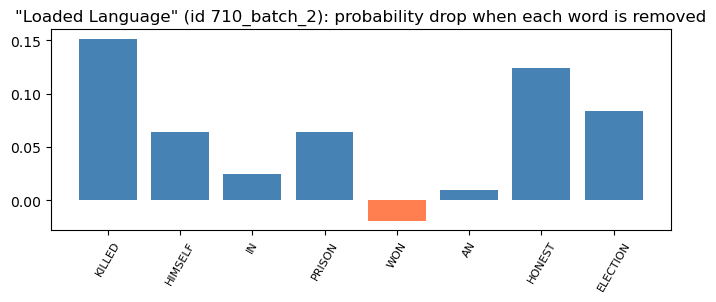

span head highlights: ['PRISON', 'HONEST']
60 cases: top-3 LOO words inside the highlight 0.47 vs chance 0.33


In [36]:
def loo(text, k):
    w = text.split()
    base = predict_texts([text])[0, k]
    return w, base - predict_texts([' '.join(w[:i] + w[i + 1:]) for i in range(len(w))])[:, k]
inside, chance = [], []
cases = [(i, k) for i in range(len(test_docs)) for k in np.where(P_test[i] == 1)[0]
         if any(t == TECHNIQUES[k] for _, _, t in test_spans[i]) and len(test_docs[i]['text'].split()) >= 4][:60]
i, k = [(i, k) for i in range(len(test_docs)) for k in np.where((P_test[i] == 1) & (Y_test[i] == 1))[0]
        if 6 <= len(test_docs[i]['text'].split()) <= 22][0]                 # first correctly predicted short meme
w, imp = loo(test_docs[i]['text'], k)
plt.figure(figsize=(8, 2.6))
plt.bar(w, imp, color=['coral' if v < 0 else 'steelblue' for v in imp])
plt.xticks(rotation=60, fontsize=8)
plt.title(f'"{TECHNIQUES[k]}" (id {test_docs[i]["id"]}): probability drop when each word is removed')
plt.show()
print('span head highlights:', [test_docs[i]['text'][s:e] for s, e, t in test_spans[i] if t == TECHNIQUES[k]])
for i, k in cases:
    text = test_docs[i]['text']
    w, imp = loo(text, k)
    cov = char_sets(text, [s for s in test_spans[i] if s[2] == TECHNIQUES[k]])[TECHNIQUES[k]]
    starts, pos = [], 0
    for x in w:
        pos = text.find(x, pos)
        starts.append(pos)
        pos += len(x)
    inn = np.array([s in cov for s in starts])
    inside.append(inn[np.argsort(-imp)[:3]].mean())
    chance.append(inn.mean())
print(f'{len(cases)} cases: top-3 LOO words inside the highlight {np.mean(inside):.2f} vs chance {np.mean(chance):.2f}')

**What came out, and how I read it**
* **The example meme** (710: KILLED HIMSELF IN PRISON / WON AN HONEST ELECTION, label *Loaded Language*):
  * the words that matter most are **KILLED** (−0.15), **HONEST** (−0.13) and **ELECTION** (−0.08);
  * the span head highlights **PRISON** and **HONEST**, so only one of the top three is actually inside the highlight;
  * removing "WON" slightly *increases* the probability, so that word was working against the label.
* **Across 60 test cases:** **47 %** of the three most important words fall inside the span highlight, compared to **33 %** you'd expect by chance.
* **What I take from this:** the highlight is a **partly faithful** explanation. It's better than chance, but most of the words driving the label sit outside it.
  * For teachers, that means the underline should be read as "where to look", not as proof of why the label was given.

---
## 9. Part C: product evaluation
Every conclusion here is based on an experiment in this notebook. The keyword lists are only used to *pick* which memes to analyse; they're never part of the tool.

### C1. Does it treat all sides the same?
**How I'm testing it**
* **C1a:** compare the real (gold) and predicted rates of accusatory labels for memes that mention each side, using all 951 held-out memes (751 out-of-fold + 200 test). Out-of-fold predictions are fair to use here because none of those memes were trained on by the model that predicted them.
* **C1b:** swap the sides in the test memes (Trump↔Biden, Republicans↔Democrats, and so on). The technique doesn't change when you swap names, so the prediction shouldn't either. I also add a **neutral-name control** (replacing names with neutral ones) to tell apart "biased against one side" from "reacts to any political name".

In [37]:
HO_Y, HO_P = np.vstack([Y_pool, Y_test]), (np.vstack([oof_doc, test_probs]) > DOC_THR).astype(int)
L_RE = r'\b(biden|democrats?|dems|liberals?|obama|hillary|clinton|pelosi|kamala|harris|bernie|sanders|aoc|antifa|leftists?|socialists?)\b'
R_RE = r'\b(trump|republicans?|conservatives?|gop|maga|pence|mcconnell|right[- ]wing)\b'
side = lambda t: {(1, 1): 'both', (1, 0): 'left terms', (0, 1): 'right terms', (0, 0): 'neither'}[(bool(re.search(L_RE, t.lower())), bool(re.search(R_RE, t.lower())))]
groups = np.array([side(d['text']) for d in pool_docs + test_docs])
rows = []
for g in ['left terms', 'right terms', 'both', 'neither']:
    m = groups == g
    gold, pred = HO_Y[m][:, ACC].max(1), HO_P[m][:, ACC].max(1)
    ci = bootstrap(*doc_counts(HO_Y[m], HO_P[m]), 500)[:, 0]
    rows.append({'group': g, 'n': int(m.sum()), 'gold accusatory': gold.mean(), 'predicted accusatory': pred.mean(),
                 'false-alarm rate': pred[gold == 0].mean(), 'macro-F1': f1c(*doc_counts(HO_Y[m], HO_P[m]))[0], 'CI': f'{ci[0]:.3f}–{ci[1]:.3f}'})
display(pd.DataFrame(rows).set_index('group').round(3))
fa = {g: HO_P[(groups == g) & (HO_Y[:, ACC].max(1) == 0)][:, ACC].max(1) for g in ['right terms', 'left terms']}
r = np.random.default_rng(SEED)
d = [r.choice(fa['right terms'], len(fa['right terms'])).mean() - r.choice(fa['left terms'], len(fa['left terms'])).mean() for _ in range(2000)]
print(f"false-alarm gap right, left: {fa['right terms'].mean() - fa['left terms'].mean():+.3f}, 95% CI [{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]")

def replace_terms(text, mapping):
    pat = re.compile(r'\b(' + '|'.join(re.escape(k) for k in sorted(mapping, key=len, reverse=True)) + r')\b', re.IGNORECASE)
    def rep(m):
        w, new = m.group(0), mapping[m.group(0).lower()]
        return new.upper() if w.isupper() else (new[0].upper() + new[1:] if w[0].isupper() else new)
    return pat.sub(rep, text)
pairs = [('trump', 'biden'), ('republicans', 'democrats'), ('republican', 'democrat'), ('conservatives', 'liberals'), ('conservative', 'liberal'),
         ('gop', 'dems'), ('pence', 'harris'), ('mcconnell', 'pelosi'), ('maga', 'antifa')]
swap = {**{a: b for a, b in pairs}, **{b: a for a, b in pairs}}
neutral = {w: 'Morgan' if w in ('trump', 'biden', 'pence', 'harris', 'mcconnell', 'pelosi') else 'members' for w in swap}
aff = [i for i, d in enumerate(test_docs) if replace_terms(d['text'], swap) != d['text']]
p0 = test_probs[aff]
dirn = np.array([side(test_docs[i]['text']) for i in aff])
rows = []
for edit, mp in [('side swap', swap), ('neutral control', neutral)]:
    p1 = predict_texts([replace_terms(test_docs[i]['text'], mp) for i in aff])
    dacc = (p1 - p0)[:, ACC].sum(1)
    for g in ['right terms', 'left terms']:
        x = dacc[dirn == g]
        bs = np.random.default_rng(SEED)
        b = [bs.choice(x, len(x)).mean() for _ in range(1000)]
        rows.append({'edit': edit, 'originally': g, 'n': len(x), 'mean Δ accusatory prob': x.mean(), 'CI': f'{np.percentile(b, 2.5):+.3f} to {np.percentile(b, 97.5):+.3f}',
                     'label sets changed': ((p1 > DOC_THR) != (p0 > DOC_THR)).any(1).mean()})
display(pd.DataFrame(rows).round(3))

,n,gold accusatory,predicted accusatory,false-alarm rate,macro-F1,CI
group,,,,,,
left terms,140,0.657,0.850,0.688,0.278,0.214–0.316
right terms,103,0.583,0.942,0.907,0.302,0.227–0.346
both,43,0.651,0.907,0.733,0.327,0.259–0.377
neither,665,0.465,0.826,0.739,0.215,0.190–0.235


false-alarm gap right, left: +0.219, 95% CI [+0.069, +0.375]


,edit,originally,n,mean Δ accusatory prob,CI,label sets changed
0,side swap,right terms,25,-0.030,-0.082 to +0.014,0.415
1,side swap,left terms,29,0.009,-0.012 to +0.032,0.415
2,neutral control,right terms,25,-0.084,-0.142 to -0.028,0.631
3,neutral control,left terms,29,-0.103,-0.146 to -0.060,0.631


**How I got to the conclusion**
1. **Is the data itself balanced?**
   * Gold accusatory rates are 0.66 for left-term memes, 0.58 for right-term memes and 0.47 for neither.
   * So the sides genuinely aren't the same in the data, and equal predicted rates would actually be *wrong*. Fairness has to be judged *within* each group, by looking at false alarms.
2. **Does the model follow the real rates?**
   * No. Predicted accusatory rates are **0.83 to 0.94** in every group, against 0.47 to 0.66 in the gold labels.
   * So it over-accuses everywhere, which is the same over-prediction from §8.
3. **Is the over-accusing the same for both sides?**
   * No. The false-alarm rate is higher for right-term memes, **0.91 vs 0.69**, and the bootstrap interval for the gap (**+0.07 to +0.38**) doesn't include zero, so it's a real difference.
   * Overall quality doesn't differ in any way I can detect though: macro-F1 is 0.278 vs 0.302 and the intervals overlap.
4. **Is it the names themselves?**
   * Swapping sides moves the accusatory probability in **no consistent direction** (−0.03 and +0.01, with both intervals crossing 0), even though it changes 42 % of the label sets.
   * The neutral-name control changes 63 % of label sets and **lowers** the accusatory probability for both sides (−0.08 and −0.10, both intervals below 0).

**Conclusion**
* There's **no evidence that the model prefers one side's names** over the other's.
* **But any political name works as a cue for accusation.** Take the names out and the accusations drop.
* The right/left gap in false alarms must be coming from **other wording** in those memes, since swapping the names didn't change it.

**Limits**
* Keywords tell me who's *mentioned*, not who's being *attacked*.
* With 43 to 140 memes per group, only fairly large effects would show up.
* If the annotations themselves are biased, I can't detect it, because the model is being scored against them.

### C2. Defending the system against a zero-shot general-purpose model
**Making it a fair comparison**
* **It has to be deployable.** Student memes can't leave the device, so the comparison model has to run **locally on a T4**. I used `Qwen2.5-1.5B-Instruct`. It's outside the labs, but the brief asks for a general-purpose model, and this is one that can actually run under the same constraints.
* **Same data and metric:** all **200 test memes**, the same metrics, and a paired bootstrap for the difference.
* **A fair prompt:** all 20 techniques **each with a one-line definition**, text-only instructions, and no examples (that's what zero-shot means).
* **Matching answers:** it has to answer with a JSON list. Shortened names are credited if they clearly match one technique, and anything that doesn't map is counted.
* **Runs:** greedy decoding (temperature 0) is the main run. Two sampled runs (T = 0.7) show how repeatable it is.
* **Contamination:** a memorisation check sees whether it can continue test memes it might have seen during pretraining.
* **Records:** model, revision, date, prompt, settings and every prediction are saved (`c2_predictions.json` and the tables below).

In [38]:
LLM_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
llm_tok = AutoTokenizer.from_pretrained(LLM_NAME)
llm = AutoModelForCausalLM.from_pretrained(LLM_NAME, torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32).to(device).eval()
DEFS = {'Appeal to authority': 'Treating a claim as true mainly because an authority or expert says it.',
        'Appeal to fear/prejudice': 'Trying to gain support by arousing fear or prejudice about an alternative or group.',
        'Black-and-white Fallacy/Dictatorship': 'Presenting only two choices when more exist, or dictating one allowed course of action.',
        'Causal Oversimplification': 'Reducing a complex event or problem to one cause, person or group.',
        'Doubt': 'Casting doubt on the credibility of a person, claim or source rather than addressing the substance.',
        'Exaggeration/Minimisation': 'Overstating or understating facts, importance or consequences.',
        'Flag-waving': 'Using patriotism or loyalty to a group as a reason to accept an idea or action.',
        'Glittering generalities (Virtue)': 'Linking a message to vague positive values or virtues so it feels desirable.',
        'Loaded Language': 'Using strongly emotional words or phrases to influence the audience.',
        "Misrepresentation of Someone's Position (Straw Man)": 'Distorting another position into an easier version to attack.',
        'Name calling/Labeling': 'Attaching a praising or insulting label to a target instead of arguing the issue.',
        'Obfuscation, Intentional vagueness, Confusion': 'Using unclear, vague, confusing or needlessly complex wording to obscure the issue.',
        'Presenting Irrelevant Data (Red Herring)': 'Distracting from the issue with information or a topic that is not relevant to the point.',
        'Reductio ad hitlerum': 'Discrediting a person or idea through association with Hitler or Nazism.',
        'Repetition': 'Repeating the same message, phrase or claim to reinforce it.',
        'Slogans': 'Using a short, memorable phrase as a persuasive substitute for fuller reasoning.',
        'Smears': "Trying to damage a target's reputation through hostile accusation or insinuation.",
        'Thought-terminating cliché': 'Using a stock phrase that shuts down further thought or discussion.',
        'Whataboutism': "Deflecting criticism by pointing to another person's similar or worse behaviour.",
        'Bandwagon': 'Arguing that something is right or desirable because many people support or do it.'}
SYSTEM = ('You are a media-literacy classifier. Classify persuasion techniques in the supplied meme TEXT only. '
          'Do not judge whether the meme is factually true, and do not infer techniques from an image you cannot see.')
USER = ('Here is the extracted text of one meme, between the lines of dashes:\n---\n{text}\n---\n\n'
        'Which of the following persuasion techniques are used in this text? A meme may use several techniques or none.\n'
        'Taxonomy and short definitions:\n{guide}\n\n'
        'Answer ONLY with a JSON list of technique names copied exactly from the taxonomy above, '
        'for example ["Loaded Language", "Smears"]. Answer [] if none apply.')
GUIDE = '\n'.join(f'- {t}: {DEFS[t]}' for t in TECHNIQUES)

def generate(messages, max_new, temperature=0.0, seed=0):
    ids = llm_tok(llm_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True), return_tensors='pt').to(device)
    torch.manual_seed(seed)
    with torch.inference_mode():
        kw = dict(do_sample=True, temperature=temperature, top_p=1.0) if temperature else dict(do_sample=False)
        out = llm.generate(**ids, max_new_tokens=max_new, pad_token_id=llm_tok.eos_token_id, **kw)
    return llm_tok.decode(out[0, ids['input_ids'].shape[1]:], skip_special_tokens=True)

def map_name(n):
    n = n.strip().lower()
    hits = [t for t in TECHNIQUES if n == t.lower()] or [t for t in TECHNIQUES if any(n == p or (len(n) > 5 and n in t.lower())
            for p in [p.strip().lower() for p in re.split(r'[/(),]', t) if len(p.strip()) > 3])]
    if len(hits) != 1 and len(w := set(re.findall(r'[a-z]+', n)) - {'to', 'of', 'the', 'a'}) >= 2:
        hits = [t for t in TECHNIQUES if w <= set(re.findall(r'[a-z]+', t.lower()))]
    return hits[0] if len(hits) == 1 else None

def parse(ans):
    try: names = json.loads(re.search(r'\[.*?\]', ans, re.S).group(0))
    except Exception: return set(), 'wrong shape'
    mapped = [map_name(str(x)) for x in names]
    return {m for m in mapped if m}, 'ok' if all(mapped) else 'unmapped name'

RUNS = [('greedy T=0', 0.0, 0), ('sampled T=0.7 s0', 0.7, 0), ('sampled T=0.7 s1', 0.7, 1)]
records, secs = [], {}
for name, temp, sd in RUNS:
    t0 = time.perf_counter()
    for d in test_docs:
        ans = generate([{'role': 'system', 'content': SYSTEM}, {'role': 'user', 'content': USER.format(text=d['text'], guide=GUIDE)}], 120, temp, sd)
        labs, status = parse(ans)
        records.append({'run': name, 'id': d['id'], 'raw': ans, 'labels': sorted(labs), 'status': status})
    secs[name] = (time.perf_counter() - t0) / len(test_docs) * 1000
    print(f'{name}: {secs[name]:.0f} ms/meme')
llm_df = pd.DataFrame(records)
display(pd.crosstab(llm_df['run'], llm_df['status']))

def cont_match(text):                       # memorisation probe: can it continue the meme word for word?
    w = text.split()
    h = len(w) // 2
    out = generate([{'role': 'user', 'content': 'Continue this meme text exactly, word for word:\n' + ' '.join(w[:h])}], 30).lower().split()
    return np.mean([a == b.lower() for a, b in zip(out, w[h:h + 8])])
mem = [cont_match(d['text']) for d in test_docs if len(d['text'].split()) >= 10][:25]
json.dump({'model': LLM_NAME, 'revision': getattr(llm.config, '_commit_hash', None), 'date': datetime.now().isoformat(timespec='seconds'),
           'system': SYSTEM, 'user_template': USER, 'definitions': DEFS, 'runs': RUNS, 'max_new_tokens': 120, 'predictions': records},
          open('c2_predictions.json', 'w'), indent=1)
del llm
torch.cuda.empty_cache()

systems = {'our model': P_test, **{f'Qwen {n}': labels_to_matrix([set(l) for l in llm_df[llm_df['run'] == n]['labels']]) for n, _, _ in RUNS}}
mask = Y_test.sum(0) > 0
rows = []
for n, P in systems.items():
    rr = np.random.default_rng(SEED)
    diff = []
    for _ in range(1000):
        i = rr.integers(0, 200, 200)
        diff.append(f1c(*doc_counts(Y_test[i], P_test[i]), mask)[0] - f1c(*doc_counts(Y_test[i], P[i]), mask)[0])
    ci = bootstrap(*doc_counts(Y_test, P))[:, 0]
    rows.append({'system': n, 'macro-F1': f1c(*doc_counts(Y_test, P))[0], 'CI': f'{ci[0]:.3f}–{ci[1]:.3f}', 'micro-F1': f1c(*doc_counts(Y_test, P))[1],
                 'labels/meme': P.sum(1).mean(), 'ours − system, 95% CI': f'{np.percentile(diff, 2.5):+.3f} to {np.percentile(diff, 97.5):+.3f}'})
display(pd.DataFrame(rows).set_index('system').round(3))
s1, s2 = [llm_df[llm_df['run'] == n]['labels'].apply(set).tolist() for n in ('sampled T=0.7 s0', 'sampled T=0.7 s1')]
print(f'run-to-run agreement (Jaccard): {np.mean([len(a & b) / len(a | b) if a | b else 1 for a, b in zip(s1, s2)]):.2f}, '
      f'memorisation: {np.mean(mem):.2f} of next words reproduced, ms/meme: ours {gpu_med:.1f}, Qwen {secs["greedy T=0"]:.0f}')
print('most frequent Qwen (greedy) answers:', Counter(l for ls in llm_df[llm_df['run'] == 'greedy T=0']['labels'] for l in ls).most_common(3))
lbl = lambda P: [', '.join(TECHNIQUES[k][:18] for k in np.where(r)[0]) or '—' for r in P]
display(HTML('<div style="max-height:300px;overflow:auto">' + pd.DataFrame({'id': [d['id'] for d in test_docs], 'gold': lbl(Y_test),
             **{n: lbl(P) for n, P in systems.items()}}).to_html(index=False) + '</div>'))

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  65%|######4   | 1.99G/3.09G [00:00<?, ?B/s]

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

greedy T=0: 359 ms/meme
sampled T=0.7 s0: 331 ms/meme
sampled T=0.7 s1: 325 ms/meme


status,ok,unmapped name
run,,
greedy T=0,199,1
sampled T=0.7 s0,198,2
sampled T=0.7 s1,199,1


,macro-F1,CI,micro-F1,labels/meme,"ours − system, 95% CI"
system,,,,,
our model,0.193,0.168–0.215,0.399,4.615,+0.000 to +0.000
Qwen greedy T=0,0.082,0.031–0.116,0.073,1.080,+0.071 to +0.166
Qwen sampled T=0.7 s0,0.030,0.016–0.045,0.058,1.065,+0.136 to +0.191
Qwen sampled T=0.7 s1,0.049,0.024–0.074,0.069,1.085,+0.111 to +0.177


run-to-run agreement (Jaccard): 0.66, memorisation: 0.03 of next words reproduced, ms/meme: ours 7.6, Qwen 359
most frequent Qwen (greedy) answers: [('Appeal to authority', 116), ('Appeal to fear/prejudice', 71), ('Doubt', 7)]


id,gold,our model,Qwen greedy T=0,Qwen sampled T=0.7 s0,Qwen sampled T=0.7 s1
705_batch_2,"Name calling/Label, Slogans","Flag-waving, Slogans",Appeal to authorit,Appeal to authorit,Flag-waving
706_batch_2,"Appeal to fear/pre, Loaded Language, Name calling/Label","Appeal to fear/pre, Doubt, Exaggeration/Minim, Flag-waving, Glittering general, Loaded Language, Misrepresentation , Name calling/Label, Reductio ad hitler, Slogans, Smears",Appeal to fear/pre,Appeal to fear/pre,Appeal to fear/pre
710_batch_2,"Loaded Language, Name calling/Label","Loaded Language, Name calling/Label",Appeal to authorit,Appeal to authorit,Appeal to authorit
713_batch_2,"Exaggeration/Minim, Loaded Language","Exaggeration/Minim, Loaded Language, Name calling/Label, Slogans, Smears",Appeal to fear/pre,Appeal to fear/pre,Appeal to fear/pre
715_batch_2,Doubt,"Doubt, Exaggeration/Minim, Glittering general, Loaded Language, Name calling/Label, Smears, Whataboutism",Appeal to authorit,Appeal to authorit,Appeal to authorit
716_batch_2,"Loaded Language, Smears, Whataboutism","Appeal to fear/pre, Loaded Language, Name calling/Label, Slogans, Smears",Appeal to fear/pre,"Glittering general, Slogans",Appeal to fear/pre
720_batch_2,"Appeal to fear/pre, Loaded Language","Exaggeration/Minim, Flag-waving, Glittering general, Loaded Language, Name calling/Label, Slogans, Smears",Appeal to fear/pre,Appeal to fear/pre,Appeal to fear/pre
722_batch_2,"Loaded Language, Reductio ad hitler","Appeal to fear/pre, Causal Oversimplif, Doubt, Exaggeration/Minim, Flag-waving, Glittering general, Loaded Language, Misrepresentation , Name calling/Label, Slogans, Smears, Whataboutism","Appeal to fear/pre, Black-and-white Fa, Causal Oversimplif, Glittering general, Reductio ad hitler","Appeal to fear/pre, Causal Oversimplif, Exaggeration/Minim, Glittering general","Appeal to fear/pre, Black-and-white Fa"
723_batch_2,Name calling/Label,—,Appeal to authorit,Appeal to authorit,Flag-waving
724_batch_2,"Exaggeration/Minim, Loaded Language, Name calling/Label, Obfuscation, Inten","Appeal to authorit, Appeal to fear/pre, Doubt, Exaggeration/Minim, Flag-waving, Glittering general, Loaded Language, Name calling/Label, Slogans, Smears",Appeal to authorit,Appeal to authorit,Appeal to authorit


**How I got to the conclusion**
1. **Same data, same measure.**
   * On all 200 test memes our model gets **0.193** and Qwen (greedy, the main run) gets **0.082**.
   * The paired bootstrap interval for the difference is **+0.071 to +0.166**, which doesn't include zero, so the gap isn't luck. The sampled Qwen runs do even worse (0.030 and 0.049).
   * The output format wasn't the problem either: 199 of 200 answers parsed fine and only 1 name couldn't be mapped.
2. **Why the LLM does so badly.**
   * It gives about **one label per meme**, and those are mostly *Appeal to authority* (116 times) and *Appeal to fear* (71). It almost never says *Loaded Language*, which is in half the test memes. You can see this in the example table, where it says *Appeal to authority* for memes like 710 and 725 that are plain name-calling.
   * So even with the definitions right there in the prompt, a small general model doesn't connect meme language to this particular set of techniques.
3. **Repeatability.** Its sampled runs only agree on about **66 %** of labels (Jaccard 0.66) for the same meme. A teacher could put the same meme in twice and get different answers.
4. **Contamination.** It only reproduces about **3 %** of the next words of a test meme, so there's no sign it memorised them. It's a weak test though, since not being able to recite a meme doesn't prove it never saw it.
5. **Cost.** 393 ms per meme against our 7.5 ms, so about **50× slower**.

**Answer for the committee:** the general-purpose model the department is actually *allowed* to use (local, on one T4) scores less than half of what the trained system does, gives inconsistent answers and is much slower. A big hosted model might do better, but it would send students' memes off the device, and the contract doesn't allow that.

**Limits**
* I only tested one small open model and one prompt wording.
* Hosted models were ruled out because of privacy, not because of how good they are.

### C3. Do the label head and the span head agree?
For every meme and technique, each prediction falls into one of three groups: both heads fire, only the label head fires (so there's nothing to point at), or only the span head fires. The gold labels then show which group tends to be right, and I score three different rules for what to display.

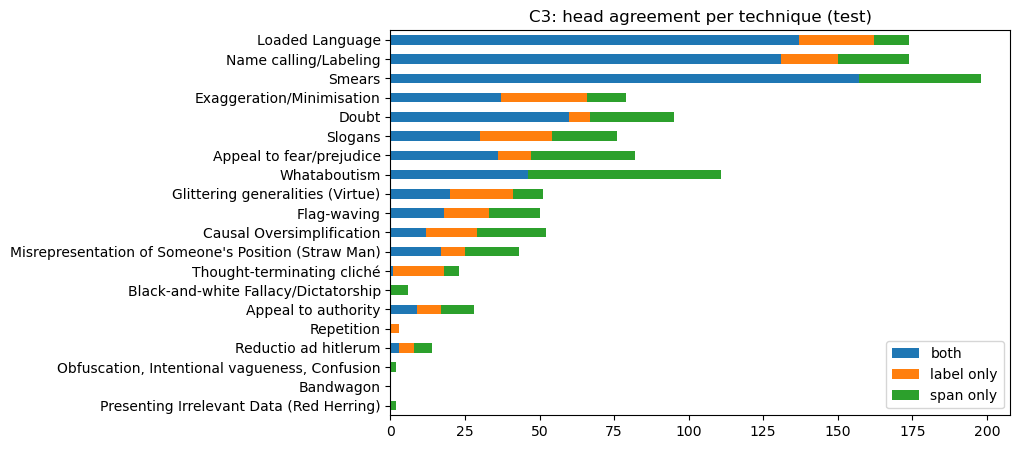

agree 714, label-only 209, span-only 340 -> disagreement 43%
technique really present when: both agree 33%, label only 7%, span only 8%


,precision,micro-F1,macro-F1,labels with nothing to point at
policy,,,,
show label head,0.272,0.399,0.193,209
show only if both agree,0.332,0.452,0.195,0
show if either fires,0.221,0.349,0.184,209


In [39]:
both, lab_only, span_only = (P_test == 1) & (span_on == 1), (P_test == 1) & (span_on == 0), (P_test == 0) & (span_on == 1)
c3 = pd.DataFrame({'both': both.sum(0), 'label only': lab_only.sum(0), 'span only': span_only.sum(0)}, index=TECHNIQUES).loc[freq_order]
c3['disagree %'] = (100 * (c3['label only'] + c3['span only']) / c3.sum(axis=1).replace(0, np.nan)).round(0)
c3[['both', 'label only', 'span only']].plot.barh(stacked=True, figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title('C3: head agreement per technique (test)')
plt.show()
print(f'agree {both.sum()}, label-only {lab_only.sum()}, span-only {span_only.sum()} -> disagreement {(lab_only.sum() + span_only.sum()) / (both.sum() + lab_only.sum() + span_only.sum()):.0%}')
print(f'technique really present when: both agree {Y_test[both].mean():.0%}, label only {Y_test[lab_only].mean():.0%}, span only {Y_test[span_only].mean():.0%}')
display(pd.DataFrame([{'policy': n, 'precision': (P * Y_test).sum() / max(P.sum(), 1), 'micro-F1': doc_scores(Y_test, P)['micro_f1'],
                       'macro-F1': doc_scores(Y_test, P)['macro_f1'], 'labels with nothing to point at': int(((P == 1) & (span_on == 0)).sum())}
                      for n, P in {'show label head': P_test, 'show only if both agree': both.astype(int), 'show if either fires': P_test | span_on}.items()]).set_index('policy').round(3))

**How I got to the conclusion**
1. **How often do the heads disagree?**
   * On **43 %** of the meme-technique pairs where at least one head fires (714 agree, 209 label-only, 340 span-only).
   * The chart shows it depends heavily on the technique. For *Loaded Language* and *Smears*, roughly 21 % of cases are disagreements, but for rare ones like *Thought-terminating cliché* or *Black-and-white* it's almost all disagreement. *Whataboutism* stands out with a lot of span-only firing, which makes sense because its spans usually cover the whole meme (§2).
2. **What does agreement tell us?**
   * When both heads fire, the technique is really there **33 %** of the time. When only one fires, it's just **7 %** (label only) or **8 %** (span only).
   * So **the two heads agreeing is the best reliability signal the system has**. It's about four times more trustworthy than either head alone.
3. **Which display rule works best?**
   * In the policy table, "only show it if both agree" gets rid of all **209** labels that had nothing to point at. Precision goes from 0.27 to 0.33 and micro-F1 from 0.399 to 0.452, and macro-F1 doesn't drop at all (0.193 → 0.195).
   * Combined with the 0.45 display threshold (the student view in §7), precision reaches 0.50.

**What the tool should actually show**
1. **Both heads agree and the probability is at least 0.45** → show it to students with the highlight. For whole-meme techniques (*Smears*, *Whataboutism*), outline the whole meme instead of underlining words.
2. **Label head only** → teacher view only, worded as "possibly X, no specific words found". It's only right 7 % of the time.
3. **Span head only** → also teacher-only, as a prompt: "do these words look like X?"

**Limits:** these rates depend on the thresholds, and I compared the rules on the same test set I'm reporting them on. They'd need confirming on new data.

### C4. Will it work for Australian Year 10 feeds in 2026?
There's no labelled Australian data, so I build the evidence by testing each part of the gap separately:
* **C4a, names:** swap US names and institutions for Australian ones and keep the gold labels. Changing who's named doesn't change the technique, so the labels still hold.
* **C4b, teen writing style:** lower-case, text-speak, emoji and typos.
* **C4c, new topics:** 26 hand-written probe memes about things like school, vaping, footy and housing, 6 of which are deliberately harmless.
* **C4d, familiarity:** the share of unseen words and the model's confidence, to see whether there's a usable "this looks unfamiliar" signal.

In [40]:
AU = {'trump': 'Dutton', 'biden': 'Albanese', 'obama': 'Rudd', 'hillary': 'Gillard', 'clinton': 'Gillard', 'pelosi': 'Wong', 'kamala': 'Marles',
      'harris': 'Marles', 'pence': 'Ley', 'democrats': 'Labor', 'democrat': 'Labor', 'dems': 'Labor', 'republicans': 'Liberals', 'republican': 'Liberal',
      'gop': 'Coalition', 'america': 'Australia', 'american': 'Australian', 'americans': 'Australians', 'usa': 'Australia', 'united states': 'Australia',
      'congress': 'Parliament', 'president': 'Prime Minister', 'white house': 'Lodge', 'washington': 'Canberra', 'fox news': 'Sky News',
      'cnn': 'the ABC', 'texas': 'Queensland', 'california': 'Victoria'}
au = [i for i, d in enumerate(test_docs) if replace_terms(d['text'], AU) != d['text']]
P_au = (predict_texts([replace_terms(test_docs[i]['text'], AU) for i in au]) > DOC_THR).astype(int)
rr = np.random.default_rng(SEED)
m_au = Y_test[au].sum(0) > 0
dd = [f1c(*doc_counts(Y_test[au][i], P_au[i]), m_au)[0] - f1c(*doc_counts(Y_test[au][i], P_test[au][i]), m_au)[0] for i in (rr.integers(0, len(au), len(au)) for _ in range(1000))]
print(f'C4a ({len(au)} memes): macro-F1 {f1c(*doc_counts(Y_test[au], P_test[au]))[0]:.3f} -> {f1c(*doc_counts(Y_test[au], P_au))[0]:.3f} '
      f'(paired CI {np.percentile(dd, 2.5):+.3f} to {np.percentile(dd, 97.5):+.3f}), label sets changed {(P_au != P_test[au]).any(1).mean():.0%}')

SLANG = {'you': 'u', 'are': 'r', 'because': 'bc', 'people': 'ppl', 'really': 'rly', 'about': 'abt', 'though': 'tho', 'your': 'ur',
         'for real': 'fr', 'something': 'smth', 'please': 'pls', 'with': 'w', 'okay': 'ok', 'to be honest': 'tbh'}
def typos(t, rate):
    r, c = random.Random(SEED), list(t)
    for i in range(len(c) - 1):
        if c[i].isalpha() and c[i + 1].isalpha() and r.random() < rate: c[i], c[i + 1] = c[i + 1], c[i]
    return ''.join(c)
T = [d['text'] for d in test_docs]
rows = []
for n, texts in {'original': None, 'lower-case': [t.lower() for t in T], 'text-speak': [replace_terms(t.lower(), SLANG) for t in T],
                 'emoji': [t.rstrip() + ' 💀😭🔥' for t in T], 'typos 5%': [typos(t, .05) for t in T], 'typos 10%': [typos(t, .10) for t in T]}.items():
    P = P_test if texts is None else (predict_texts(texts) > DOC_THR).astype(int)
    ci = bootstrap(*doc_counts(Y_test, P), 500)[:, 0]
    rows.append({'condition': n, 'macro-F1': f1c(*doc_counts(Y_test, P))[0], 'CI': f'{ci[0]:.3f}–{ci[1]:.3f}', 'label sets changed': (P != P_test).any(1).mean()})
display(pd.DataFrame(rows).set_index('condition').round(3))

PROBE = [("THE GREENS WANT TO TAX YOUR PETROL, YOUR MEAT AND YOUR FUN. WHAT'S NEXT, YOUR OXYGEN?", ['Exaggeration/Minimisation', 'Appeal to fear/prejudice'], 'AU politics'),
         ("Labor: wrecking the economy since forever", ['Smears', 'Loaded Language'], 'AU politics'),
         ("The Liberals: wrecking the planet since forever", ['Smears', 'Loaded Language'], 'AU politics'),
         ("CLUELESS PM strikes again", ['Name calling/Labeling', 'Loaded Language'], 'AU politics'),
         ("Australia first. Always.", ['Flag-waving', 'Slogans'], 'AU politics'),
         ("Do we really know where the council spends our money? Just asking.", ['Doubt'], 'AU politics'),
         ("So the teachers' union says they want better pay. Translation: they want to do less work.", ["Misrepresentation of Someone's Position (Straw Man)"], 'AU politics'),
         ("If housing gets more expensive again, thank the greedy boomers.", ['Causal Oversimplification', 'Loaded Language'], 'AU politics'),
         ("Real Aussies back our farmers. Everyone else is already on board.", ['Flag-waving', 'Bandwagon'], 'AU politics'),
         ("Climate protest? What about the cars the protesters drove to the rally?", ['Whataboutism'], 'AU politics'),
         ("Everyone at school already has the new phone. Don't be the only loser without one.", ['Bandwagon', 'Name calling/Labeling'], 'teen'),
         ("Either you support the phone ban or you don't care about kids' mental health.", ['Black-and-white Fallacy/Dictatorship'], 'teen'),
         ("Vaping is the reason for ALL the problems in our schools.", ['Causal Oversimplification', 'Exaggeration/Minimisation'], 'teen'),
         ("Leading scientists agree: this energy drink makes you smarter.", ['Appeal to authority'], 'teen'),
         ("They want to ban social media for under 16s. Next they'll ban talking.", ['Exaggeration/Minimisation'], 'teen'),
         ("It is what it is. Stop overthinking it.", ['Thought-terminating cliché'], 'teen'),
         ("Our footy club: courage, loyalty, family.", ['Glittering generalities (Virtue)'], 'teen'),
         ("Stop the waste! Stop the waste! Stop the waste!", ['Slogans', 'Repetition'], 'teen'),
         ("The new principal acts like a dictator. Remind you of a certain 1930s German leader?", ['Reductio ad hitlerum', 'Name calling/Labeling'], 'teen'),
         ("Bushfires, floods, and now a uniform change. Be very afraid.", ['Appeal to fear/prejudice'], 'teen'),
         ("Year 10 camp is next week, remember to pack sunscreen.", [], 'neutral'), ("When the bell rings but the teacher keeps talking", [], 'neutral'),
         ("Me trying to study for exams at 2am", [], 'neutral'), ("The canteen now sells sushi on Fridays.", [], 'neutral'),
         ("Footy finals this weekend! Who's going?", [], 'neutral'), ("Library closes at 4pm during exam week.", [], 'neutral')]
pt = [p[0] for p in PROBE]
pY = labels_to_matrix([set(p[1]) for p in PROBE])
kind = np.array([p[2] for p in PROBE])
pp = predict_texts(pt)
pP = (pp > DOC_THR).astype(int)
pers = kind != 'neutral'
display(pd.DataFrame({'text': pt, 'intended': [short(set(p[1])) for p in PROBE], 'predicted': [short({TECHNIQUES[k] for k in np.where(r)[0]}) for r in pP],
                      'max p': pp.max(1).round(2)}))
print(f'persuasive probes: macro-F1 {f1c(*doc_counts(pY[pers], pP[pers]))[0]:.3f}, >=1 intended technique found {((pP * pY).sum(1) > 0)[pers].mean():.0%}, '
      f'harmless probes flagged: {pP[~pers].any(1).sum()}/{(~pers).sum()}')

vocab = set(w for d in pool_docs for w in re.findall(r"[a-z']+", d['text'].lower()))
oov = lambda ts: np.mean([w not in vocab for t in ts for w in re.findall(r"[a-z']+", t.lower())])
sets = {'test': (T, test_probs), 'test Australianised': ([replace_terms(test_docs[i]['text'], AU) for i in au], None),
        'probes AU politics': (np.array(pt)[kind == 'AU politics'], pp[kind == 'AU politics']), 'probes teen': (np.array(pt)[kind == 'teen'], pp[kind == 'teen']),
        'probes harmless': (np.array(pt)[kind == 'neutral'], pp[kind == 'neutral'])}
sets['test Australianised'] = (sets['test Australianised'][0], predict_texts(sets['test Australianised'][0]))
display(pd.DataFrame({n: {'unseen words': oov(ts), 'mean max prob': p.max(1).mean(), 'no label shown': (p <= DOC_THR).all(1).mean()} for n, (ts, p) in sets.items()}).T.round(3))

C4a (71 memes): macro-F1 0.216 -> 0.270 (paired CI -0.001 to +0.080), label sets changed 66%


,macro-F1,CI,label sets changed
condition,,,
original,0.193,0.168–0.215,0.000
lower-case,0.193,0.168–0.215,0.000
text-speak,0.188,0.163–0.212,0.300
emoji,0.192,0.166–0.215,0.345
typos 5%,0.177,0.143–0.207,0.805
typos 10%,0.123,0.099–0.143,0.845


,text,intended,predicted,max p
0,"THE GREENS WANT TO TAX YOUR PETROL, YOUR MEAT ...","Appeal to fear, Exaggeration","Appeal to fear, Loaded Language, Name calling,...",0.68
1,Labor: wrecking the economy since forever,"Loaded Language, Smears","Appeal to fear, Flag-waving, Loaded Language, ...",0.62
2,The Liberals: wrecking the planet since forever,"Loaded Language, Smears","Flag-waving, Loaded Language, Name calling, Sl...",0.66
3,CLUELESS PM strikes again,"Loaded Language, Name calling","Loaded Language, Name calling, Smears",0.57
4,Australia first. Always.,"Flag-waving, Slogans",—,0.23
5,Do we really know where the council spends our...,Doubt,Doubt,0.41
6,So the teachers' union says they want better p...,Misrepresentatio,"Doubt, Loaded Language, Name calling, Smears, ...",0.61
7,"If housing gets more expensive again, thank th...","Causal Oversimpl, Loaded Language","Loaded Language, Name calling, Smears",0.78
8,Real Aussies back our farmers. Everyone else i...,"Bandwagon, Flag-waving","Loaded Language, Name calling, Smears",0.49
9,Climate protest? What about the cars the prote...,Whataboutism,"Doubt, Loaded Language",0.31


persuasive probes: macro-F1 0.112, >=1 intended technique found 40%, harmless probes flagged: 1/6


,unseen words,mean max prob,no label shown
test,0.165,0.536,0.105
test Australianised,0.205,0.587,0.085
probes AU politics,0.216,0.536,0.100
probes teen,0.182,0.432,0.200
probes harmless,0.370,0.204,0.833


**How I got to each finding**
1. **Names (C4a).**
   * Swapping in Australian names changes **66 %** of label sets on the 71 memes it applies to. Macro-F1 actually goes *up* (0.216 → 0.270), though the paired interval (−0.001 to +0.080) just includes zero.
   * That fits with C1: taking out US names takes away some of the false accusations. The main point is that the model's output depends a lot on which names appear, so **its US test score doesn't tell us much about how it'll behave on Australian politics**.
2. **Writing style (C4b).**
   * Lower-case changes nothing, which is expected with an uncased encoder. Text-speak and emoji barely move macro-F1 (0.188 and 0.192), but they still change 30 to 35 % of the answers. **10 % typos** drop macro-F1 to **0.123**, and that interval (0.099–0.143) sits entirely below the original one (0.168–0.215). Even 5 % typos change 80 % of the label sets.
   * So fast, messy teen typing is a real risk. The scores might look okay with light noise, but the actual answers students see would keep changing.
3. **New topics (C4c).**
   * At least one intended technique is found in only **40 %** of the persuasive probes (macro-F1 0.112). Most of the political and school probes come back as some mix of *Loaded Language*, *Name calling* and *Smears*, whatever the actual technique is. For example "Leading scientists agree…" gets *Smears* instead of *Appeal to authority*, and "Stop the waste!" ×3 doesn't get *Repetition*.
   * **1 of the 6** harmless memes gets flagged ("The canteen now sells sushi on Fridays" → the accusatory trio, though only at 0.31).
   * Fairness check: the Labor and Liberals mirror pair ("wrecking the economy/planet since forever") both get flagged with a similar set of labels and similar confidence (0.62 vs 0.66), although Labor's version also picks up *Appeal to fear*.
4. **Familiarity (C4d).**
   * Harmless memes have the most unseen words (37 %) and get low confidence (mean max probability 0.20, with nothing shown 83 % of the time).
   * So **low confidence works as a "teacher, please check this" trigger**. The catch is that the Australianised political memes stay confident (0.59) while being unreliable, so confidence on its own isn't enough to flag every problem.

**What this means outside the model**
* **For the teacher:** the tool is weakest on exactly the kind of material the lesson is about. The teacher needs to see the output first and use it as a starting point ("Do you agree? Which words?").
* **For a student whose family's politics are on screen:** the accusation bias from C1 makes this a real risk. Labels have to describe the *text*, never a side. Accusatory labels only get shown under the C3 rule, and each lesson should apply the technique to both sides.
* **Accountability:** Litmus owns the errors. Teacher overrides get logged on the device, and students and parents need a way to challenge a label.

**Limits**
* The name swap keeps the US topics, so it only isolates the names.
* I wrote the probes myself, so they're a sanity check, not a performance estimate.
* None of this replaces a proper labelled Australian pilot set.

---
## 10. Final judgment
**The final model, and why it ended up like this.** Each piece was only added because something I measured led to a test, and that test won in at least 4 of 5 folds (§5):
* **Frozen encoder:** LoRA and full fine-tuning both over-fitted on 540 memes per fold.
* **Class weighting:** without it, 15 of the 20 techniques were never predicted.
* **Head learning rate 4e-4:** weighting made the heads over-fit, and gentler updates fixed it.
* **BERT-base:** after that, training was still improving at the epoch limit, and better features were the fix.
* **Thresholds:** 0.25 for labels, 0.3 for spans and 0.45 for the student display, all set on development data only.

Things I tested and rejected: LoRA, full fine-tuning, separate models (λ = 0), a BiLSTM span head and more dropout. None of them passed the rule.

The final model meets the hardware constraint (7.5 ms per meme on one T4) and clearly beats the zero-shot alternative the department could actually deploy (C2).

**Performance against the targets from §3** (numbers from §7)

| | Test (95 % CI) | Minimum | Verdict |
|---|---|---|---|
| Part A macro-F1 | 0.193 (0.168–0.215) | 0.28 | below it, across the whole interval |
| Part A micro-F1 | 0.399 | > 0.424 (top-3) | fails (the student view gets 0.481, which passes) |
| Part B char macro-F1 | 0.139 (0.121–0.153) | 0.16, and > painting (0.103) | below 0.16, but it does beat painting, so the localisation works |

**Limitations, with the evidence for each and what would fix it**
* **It over-predicts accusatory labels.** 155 of 200 test memes get a wrong accusatory label, and 76 in the student view (§7–8). → Penalise false accusatory labels during training, and check the display rule on new data.
* **Rare techniques basically can't be learned.** Six score F1 = 0, all with 18 or fewer training memes (§8). → Collect 30 to 50 teacher-labelled Australian examples of each, and mark them as "not supported" until then.
* **Political names act as an accusation cue** (C1, C4a). → Replace names with placeholders during training, then re-run the swap tests.
* **It's fragile to typos** (C4b). → Train with spelling noise.
* **Training was still improving at the epoch limit** (§5.6, and seed 43 in §6). → Use a larger epoch budget, set in advance this time.
* **Text only.** It can't see the image, which some techniques depend on. → Say so clearly in the teacher guide.
* **The test set is small** (200 memes, and some techniques appear only once). → Build an Australian pilot set of at least 300 memes.

**Recommendation**
* **Don't deploy it as something that labels memes on its own.** It misses its own minimum targets, adds accusations that aren't there, and is least reliable on exactly the Australian teen material it's meant for.
* **Ship it as an assistant with the teacher in the loop:**
  * the teacher sees the output first;
  * students only see labels that pass the C3 rule and the 0.45 threshold, worded about the text, not about anyone;
  * accusatory, rare and low-confidence labels go to the teacher only;
  * lessons apply each technique to both sides;
  * teacher overrides are logged on the device.
* **Only drop the teacher filter once an Australian pilot set shows** macro-F1 of at least 0.50, accusatory precision of at least 0.70, and no side asymmetry in a repeat of C1.

---